# Federated Transfer Learning for Diabetes Prediction
## Cross-Dataset Generalisation with Explainable AI (XFTL-Diabetes)

**Datasets:** UCI Sylhet · Mendeley Iraqi · PIMA Indians  
**Framework:** FedAvg + FedProx + Supervised Contrastive Learning + SHAP/LIME XAI


## 0 · Install & Imports

In [ ]:
!pip install shap lime scikit-learn torch xgboost lightgbm catboost scipy matplotlib seaborn pandas numpy

In [ ]:
import warnings, os, random, copy
from collections import Counter
warnings.filterwarnings("ignore")
print("Dependencies loaded.")


Dependencies loaded.


In [ ]:

import json
import warnings
import os
import random
import copy
import itertools
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import wilcoxon, spearmanr

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    brier_score_loss,
    confusion_matrix,
    roc_curve,
    ConfusionMatrixDisplay
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import xgboost as xgb
import lightgbm as lgb
import catboost as cb
import shap
import lime
import lime.lime_tabular

In [ ]:
# Reproducibility
SEED = 42

def set_seed(s=SEED):
    random.seed(s)
    np.random.seed(s)
    torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    os.environ["PYTHONHASHSEED"] = str(s)

set_seed()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [ ]:
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
})
COLORS = ["#2196F3", "#4CAF50", "#FF5722"]

warnings.filterwarnings("ignore")
print(f"Seed={SEED} Device={DEVICE}")
print("Dependencies and libraries loaded.")

Seed=42 Device=cuda
Dependencies and libraries loaded.


## 1 · Data Loading

In [ ]:
URL_MENDELEY = ("https://raw.githubusercontent.com/Md-Tanzim-Hossain/"
                "FederatedTransfer_Diabetes/refs/heads/main/"
                "Mendeley_Dataset%20of%20Diabetes.csv")
URL_PIMA = ("https://raw.githubusercontent.com/Md-Tanzim-Hossain/"
            "FederatedTransfer_Diabetes/refs/heads/main/PIMA_diabetes.csv")
URL_UCI = ("https://raw.githubusercontent.com/Md-Tanzim-Hossain/"
           "FederatedTransfer_Diabetes/refs/heads/main/"
           "UCI_diabetes_data_upload.csv")

def load_all_datasets():
    df_men = pd.read_csv(URL_MENDELEY)
    df_pim = pd.read_csv(URL_PIMA)
    df_uci = pd.read_csv(URL_UCI)
    print(f" Mendeley : {df_men.shape}")
    print(f" PIMA     : {df_pim.shape}")
    print(f" UCI      : {df_uci.shape}")
    return df_men, df_pim, df_uci

print("[1] Loading datasets …")
df_men_raw, df_pim_raw, df_uci_raw = load_all_datasets()
print("Done.")

[1] Loading datasets …
 Mendeley : (1000, 14)
 PIMA     : (768, 9)
 UCI      : (520, 17)
Done.


#2. PREPROCESSING

In [ ]:
UCI_SYMPTOM_COLS = [
    "Polyuria", "Polydipsia", "sudden weight loss", "weakness", "Polyphagia",
    "Genital thrush", "visual blurring", "Itching", "Irritability", "delayed healing",
    "partial paresis", "muscle stiffness", "Alopecia", "Obesity"
]
UCI_FEATURE_COLS = ["Age", "Gender"] + UCI_SYMPTOM_COLS
MEN_FEATURE_COLS = ["Gender", "AGE", "Urea", "Cr", "HbA1c", "Chol", "TG", "HDL", "LDL", "VLDL", "BMI"]
PIMA_ZERO_COLS = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
PIMA_FEATURE_COLS = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness",
                     "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]

In [ ]:
def preprocess_uci(df):
    df = df.copy()
    df["label"] = (df["class"].str.strip().str.lower() == "positive").astype(int)
    df["Gender"] = df["Gender"].str.strip().str.lower().map({"male": 1, "female": 0}).fillna(0).astype(int)
    for col in UCI_SYMPTOM_COLS:
        df[col] = df[col].str.strip().str.lower().map({"yes": 1, "no": 0}).fillna(0).astype(int)
    df["Age"] = pd.to_numeric(df["Age"], errors="coerce").fillna(df["Age"].median()).astype(float)
    df = df[UCI_FEATURE_COLS + ["label"]].reset_index(drop=True)
    print(f" UCI: shape={df.shape}, pos_rate={df['label'].mean():.3f}")
    return df, UCI_FEATURE_COLS[:]

def preprocess_mendeley(df):
    df = df.copy()
    df.drop(columns=["ID", "No_Pation"], inplace=True, errors="ignore")
    cls = df["CLASS"].str.strip().str.upper()
    df["label_3cls"] = cls.map({"N": 0, "P": 1, "Y": 2}).fillna(0).astype(int)
    df["label"] = (df["label_3cls"] == 2).astype(int)
    df["Gender"] = df["Gender"].str.strip().str.upper().map({"M": 1, "F": 0}).fillna(0).astype(int)
    for col in ["AGE", "Urea", "Cr", "HbA1c", "Chol", "TG", "HDL", "LDL", "VLDL", "BMI"]:
        df[col] = pd.to_numeric(df[col], errors="coerce")
        df[col].fillna(df[col].median(), inplace=True)
    df = df[MEN_FEATURE_COLS + ["label", "label_3cls"]].reset_index(drop=True)
    print(f" Mendeley: shape={df.shape}, pos_rate={df['label'].mean():.3f}")
    return df, MEN_FEATURE_COLS[:]

def preprocess_pima(df):
    df = df.copy()
    for col in PIMA_ZERO_COLS:
        df[col] = df[col].replace(0, np.nan)
        df[col].fillna(df[col].median(), inplace=True)
    df.rename(columns={"Outcome": "label"}, inplace=True)
    df = df[PIMA_FEATURE_COLS + ["label"]].reset_index(drop=True)
    print(f" PIMA: shape={df.shape}, pos_rate={df['label'].mean():.3f}")
    return df, PIMA_FEATURE_COLS[:]

df_uci, feats_uci = preprocess_uci(df_uci_raw)
df_men, feats_men = preprocess_mendeley(df_men_raw)
df_pim, feats_pim = preprocess_pima(df_pim_raw)



 UCI: shape=(520, 17), pos_rate=0.615
 Mendeley: shape=(1000, 13), pos_rate=0.844
 PIMA: shape=(768, 9), pos_rate=0.349


In [ ]:
# FEATURE-LABEL LEAKAGE AUDIT
def feature_label_audit(df, feature_cols, name):
    """Report Spearman |ρ| between each feature and the label."""
    corrs = {}
    for col in feature_cols:
        r, p = spearmanr(df[col], df["label"])
        corrs[col] = abs(r)
    corrs = dict(sorted(corrs.items(), key=lambda x: -x[1]))
    top5 = list(corrs.items())[:5]
    print(f"\n [{name}] Top-5 feature–label |Spearman ρ|:")
    for feat, r in top5:
        print(f" {feat:35s}: ρ={r:.4f}")
    max_r = max(corrs.values())
    n_high = sum(1 for v in corrs.values() if v > 0.7)
    print(f" Max ρ={max_r:.4f}, Features with ρ>0.70: {n_high}")
    if max_r > 0.85:
        print(f"HIGH CORRELATION — dataset may be near-trivially separable.")
    return corrs

corr_uci = feature_label_audit(df_uci, feats_uci, "UCI")
corr_men = feature_label_audit(df_men, feats_men, "Mendeley")
corr_pim = feature_label_audit(df_pim, feats_pim, "PIMA")



 [UCI] Top-5 feature–label |Spearman ρ|:
 Polyuria                           : ρ=0.6659
 Polydipsia                         : ρ=0.6487
 Gender                             : ρ=0.4492
 sudden weight loss                 : ρ=0.4366
 partial paresis                    : ρ=0.4323
 Max ρ=0.6659, Features with ρ>0.70: 0

 [Mendeley] Top-5 feature–label |Spearman ρ|:
 HbA1c                              : ρ=0.5734
 BMI                                : ρ=0.5679
 AGE                                : ρ=0.4798
 TG                                 : ρ=0.2245
 VLDL                               : ρ=0.2245
 Max ρ=0.5734, Features with ρ>0.70: 0

 [PIMA] Top-5 feature–label |Spearman ρ|:
 Glucose                            : ρ=0.4814
 Age                                : ρ=0.3090
 BMI                                : ρ=0.3070
 Insulin                            : ρ=0.2744
 SkinThickness                      : ρ=0.2157
 Max ρ=0.4814, Features with ρ>0.70: 0


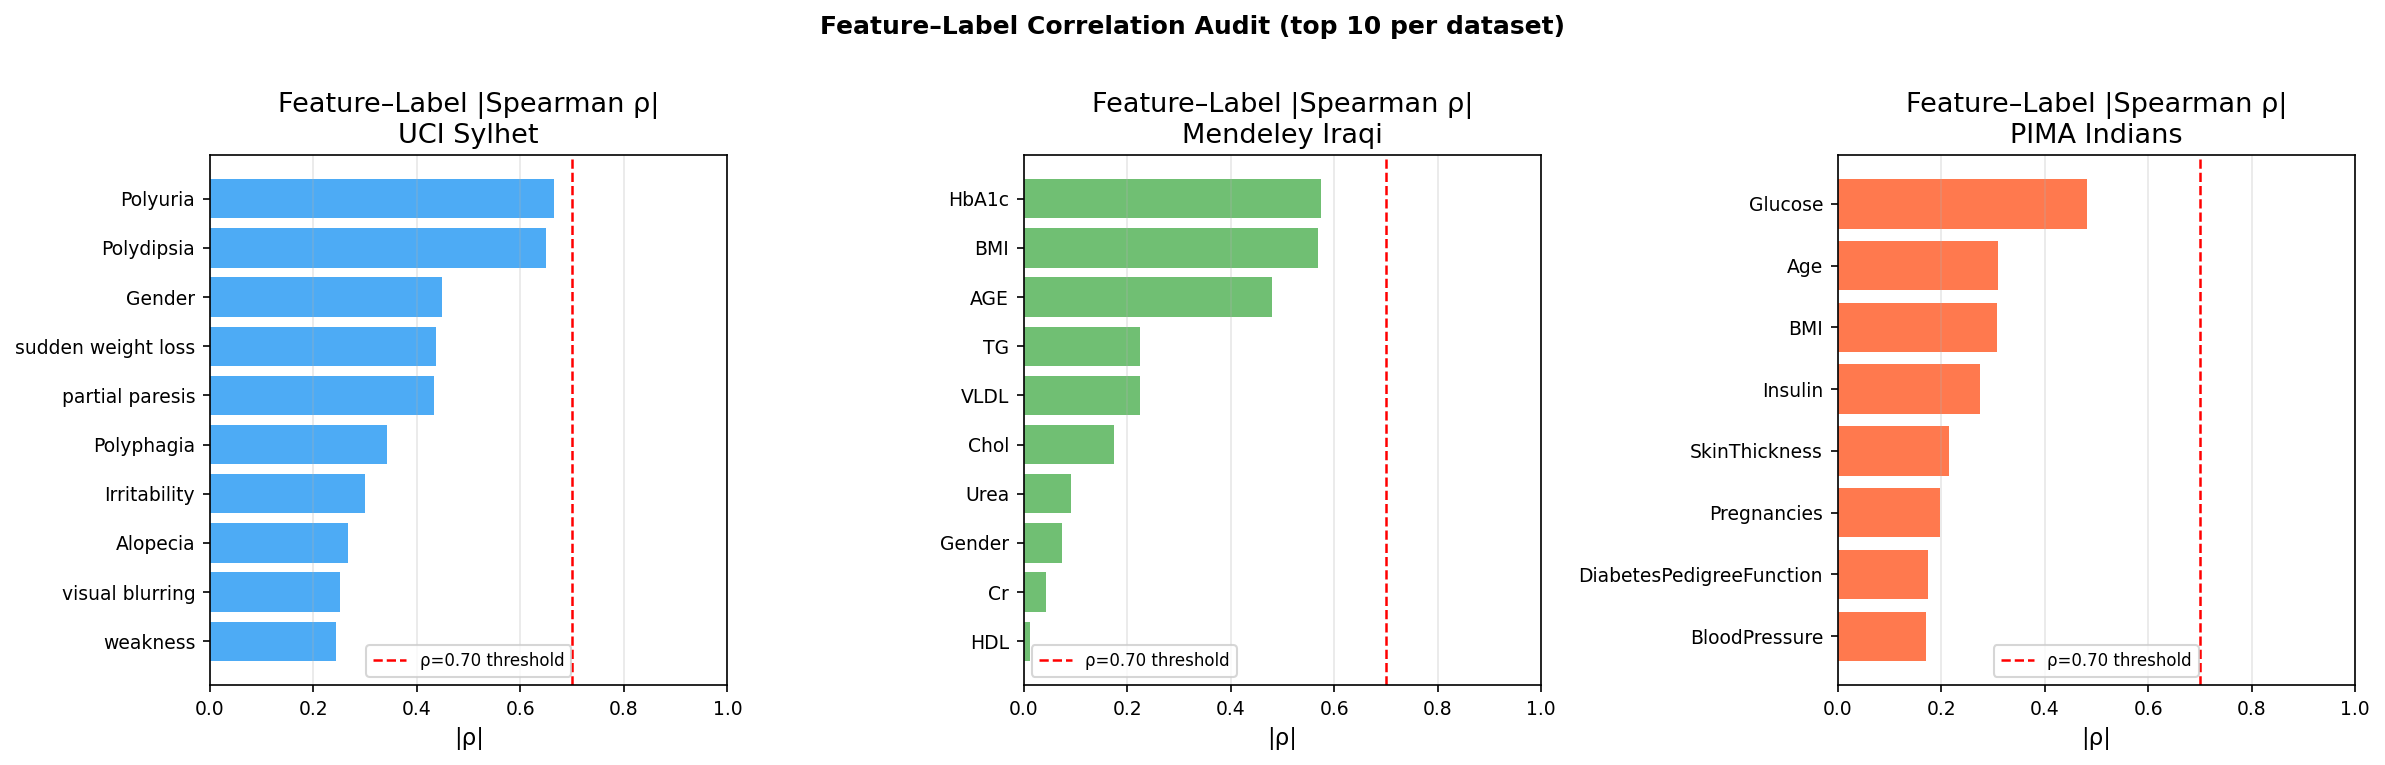

In [ ]:
# Visualise top correlations per dataset
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (corrs, name, col) in zip(axes, [
    (corr_uci, "UCI Sylhet", COLORS[0]),
    (corr_men, "Mendeley Iraqi", COLORS[1]),
    (corr_pim, "PIMA Indians", COLORS[2])
]):
    top = dict(list(corrs.items())[:10])
    ax.barh(list(top)[::-1], list(top.values())[::-1], color=col, alpha=0.8)
    ax.axvline(0.7, color="red", lw=1.2, ls="--", label="ρ=0.70 threshold")
    ax.set(title=f"Feature–Label |Spearman ρ|\n{name}", xlabel="|ρ|", xlim=(0, 1))
    ax.legend(fontsize=8)
    ax.grid(axis="x", alpha=0.3)

plt.suptitle("Feature–Label Correlation Audit (top 10 per dataset)", fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("feature_label_audit.png", dpi=600, bbox_inches="tight")
plt.show()

## 2 · Clinical Groups

In [ ]:
CLINICAL_GROUPS = {
    "demographic": ["age", "gender", "pregnancies"],
    "glycemic": ["hba1c", "glucose"],
    "anthropometric": ["bmi", "skinthickness"],
    "renal_metabolic": ["urea", "cr", "bloodpressure"],
    "lipid": ["chol", "tg", "hdl", "ldl", "vldl", "insulin", "diabetespedigreefunction"],
    "symptoms": ["polyuria", "polydipsia", "sudden weight loss", "weakness", "polyphagia",
                 "genital thrush", "visual blurring", "itching", "irritability",
                 "delayed healing", "partial paresis", "muscle stiffness", "alopecia", "obesity"],
}

In [ ]:
def assign_clinical_groups(feature_cols):
    out = {}
    for feat in feature_cols:
        fl = feat.lower().strip()
        placed = False
        for grp, kws in CLINICAL_GROUPS.items():
            if any(kw in fl for kw in kws):
                out[feat] = grp
                placed = True
                break
        if not placed:
            out[feat] = "other"
    return out

In [ ]:
grp_uci = assign_clinical_groups(feats_uci)
grp_men = assign_clinical_groups(feats_men)
grp_pim = assign_clinical_groups(feats_pim)

for nm, g in [("UCI", grp_uci), ("Mendeley", grp_men), ("PIMA", grp_pim)]:
    print(f" {nm}: {dict(Counter(g.values()))}")

 UCI: {'demographic': 2, 'symptoms': 14}
 Mendeley: {'demographic': 2, 'renal_metabolic': 2, 'glycemic': 1, 'lipid': 5, 'anthropometric': 1}
 PIMA: {'demographic': 2, 'glycemic': 1, 'renal_metabolic': 1, 'anthropometric': 2, 'lipid': 2}


#4. Data Utilities

In [ ]:
def prepare_tensors(df, feature_cols, scaler=None, fit_scaler=True):
    X = df[feature_cols].values.astype(np.float32)
    y = df["label"].values.astype(np.float32)
    if scaler is None:
        scaler = StandardScaler()
    X = scaler.fit_transform(X) if fit_scaler else scaler.transform(X)
    return (torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32), scaler)

In [ ]:
def make_loader(X_t, y_t, batch_size=32, shuffle=True):
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle, drop_last=False)


In [ ]:
def compute_metrics(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    except ValueError:
        tn = fp = fn = tp = 0
    d1, d2 = tp + fn + 1e-8, tn + fp + 1e-8
    return {
        "AUROC": roc_auc_score(y_true, y_prob),
        "AUPRC": average_precision_score(y_true, y_prob),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "BalancedAcc": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Sensitivity": tp / d1,
        "Specificity": tn / d2,
        "Brier": brier_score_loss(y_true, y_prob),
        "Accuracy": (tp + tn) / (tp + tn + fp + fn + 1e-8),
    }

In [ ]:
def bootstrap_ci(y_true, y_prob, metric_fn=roc_auc_score, n_boot=1000, ci=95):
    scores, n = [], len(y_true)
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        try:
            scores.append(metric_fn(y_true[idx], y_prob[idx]))
        except:
            pass
    a = (100 - ci) / 2
    return np.mean(scores), np.percentile(scores, a), np.percentile(scores, 100 - a)

print("Data utilities defined.")

Data utilities defined.


In [ ]:
def make_loader(X_t, y_t, batch_size=32, shuffle=True, drop_last=False):
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)

# TRAIN / VALIDATION SPLIT
raw_data = [
    ("UCI", df_uci, feats_uci, 2),
    ("Mendeley", df_men, feats_men, 2),
    ("PIMA", df_pim, feats_pim, 2),
]
clients_data, scalers = [], {}
for name, df, feats, ncls in raw_data:
    df_tr, df_va = train_test_split(df, test_size=0.2, stratify=df["label"], random_state=SEED)
    Xtr, ytr, sc = prepare_tensors(df_tr, feats)
    Xva, yva, _ = prepare_tensors(df_va, feats, sc, fit_scaler=False)
    scalers[name] = sc
    clients_data.append({
        "name": name,
        "train_loader": make_loader(Xtr, ytr, 32, drop_last=True),
        "val_loader": make_loader(Xva, yva, 64, shuffle=False, drop_last=False),
        "input_dim": len(feats),
        "n_samples": len(df_tr),
        "num_classes": ncls,
        "feature_cols": feats,
        "X_train": Xtr,
        "y_train": ytr,
        "X_val": Xva,
        "y_val": yva,
        "df_full": df,
        "scaler": sc,
    })
    print(f" {name}: train={len(df_tr)}, val={len(df_va)}, pos_rate={ytr.mean():.3f})")

 UCI: train=416, val=104, pos_rate=0.615)
 Mendeley: train=800, val=200, pos_rate=0.844)
 PIMA: train=614, val=154, pos_rate=0.349)


#5. Model Architecture

In [ ]:
class LocalEncoder(nn.Module):
    """Client-specific encoder: raw features to latent_dim."""
    def __init__(self, input_dim, latent_dim=64, dropout=0.3):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, latent_dim),
            nn.BatchNorm1d(latent_dim),
            nn.ReLU(),
            nn.Dropout(dropout))
        self.shared_net = nn.Sequential(
            nn.Linear(latent_dim, latent_dim//2),
            nn.BatchNorm1d(latent_dim//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(latent_dim//2, latent_dim),
            nn.LayerNorm(latent_dim))

    def forward(self, x):
        return self.shared_net(self.input_layer(x))


In [ ]:
class SharedProjector(nn.Module):
    """
    NEW: Projects latent to common semantic space (proj_dim=32).
    This module iS federated (aggregated via FedAvg), enabling cross-dataset transfer.
    """
    def __init__(self, latent_dim=64, proj_dim=32, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, proj_dim),
            nn.LayerNorm(proj_dim),
            nn.ReLU(),
            nn.Dropout(dropout))
        self.proj_dim = proj_dim

    def forward(self, z):
        return self.net(z)


In [ ]:
class GlobalHead(nn.Module):
    """Shared binary classifier operating on projected space."""
    def __init__(self, proj_dim=32, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(proj_dim, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1))

    def forward(self, z_proj):
        return self.net(z_proj)

In [ ]:
class LocalHead(nn.Module):
    """Client-specific head — NOT federated."""
    def __init__(self, latent_dim=64, num_classes=2, dropout=0.2):
        super().__init__()
        out = 1 if num_classes == 2 else num_classes
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, out))
        self.num_classes = num_classes

    def forward(self, z):
        return self.net(z)

In [ ]:
class XFTLClient(nn.Module):
    """LocalEncoder -> SharedProjector -> GlobalHead (federated path) -> LocalHead (private path)"""
    def __init__(self, input_dim, latent_dim=64, proj_dim=32, num_classes=2, dropout=0.3):
        super().__init__()
        self.encoder = LocalEncoder(input_dim, latent_dim, dropout)
        self.projector = SharedProjector(latent_dim, proj_dim, dropout)
        self.global_head = GlobalHead(proj_dim, dropout)
        self.local_head = LocalHead(latent_dim, num_classes, dropout)
        self.latent_dim = latent_dim
        self.proj_dim = proj_dim

    def forward(self, x, use_global=True):
        z = self.encoder(x)
        if use_global:
            return self.global_head(self.projector(z)), z
        return self.local_head(z), z

    def get_projection(self, x):
        with torch.no_grad():
            return self.projector(self.encoder(x))

print("Model architecture defined (LocalEncoder + SharedProjector + GlobalHead + LocalHead).")

Model architecture defined (LocalEncoder + SharedProjector + GlobalHead + LocalHead).


#6. Loss Functions

In [ ]:
class SupervisedContrastiveLoss(nn.Module):
    def __init__(self, temperature=0.1):
        super().__init__()
        self.T = temperature

    def forward(self, z1, z2, l1, l2):
        z1 = F.normalize(z1, dim=1)
        z2 = F.normalize(z2, dim=1)
        sim = torch.mm(z1, z2.T) / self.T
        pos = (l1.view(-1,1) == l2.view(1,-1)).float()
        log_prob = sim - torch.log(torch.exp(sim).sum(1, keepdim=True) + 1e-8)
        loss = -(pos * log_prob).sum(1) / pos.sum(1).clamp(min=1)
        return loss.mean()


In [ ]:
class FedProxLoss(nn.Module):
    def __init__(self, mu=0.01):
        super().__init__()
        self.mu = mu

    def forward(self, local_params, global_params):
        return (self.mu/2) * sum(torch.norm(lp - gp.detach())**2 for lp, gp in zip(local_params, global_params))

In [ ]:

def combined_loss(logit, label, z1=None, z2=None, l1=None, l2=None, global_params=None, local_params=None, lam1=0.3, lam2=0.1, lam3=0.01):
    L = F.binary_cross_entropy_with_logits(logit.squeeze(), label.float())
    total = L
    if z1 is not None and z2 is not None:
        if l1 is not None and l2 is not None:
            total += lam1 * SupervisedContrastiveLoss()(z1, z2, l1, l2)
            total += lam2 * F.mse_loss(z1.mean(0), z2.mean(0))
    if global_params and local_params:
        total += FedProxLoss(lam3)(local_params, global_params)
    return total, L

print("Loss functions defined.")

Loss functions defined.


#7. Federated Training

In [ ]:
def _local_epoch(model, loader, optimizer, g_params, other_z, other_y, lam1, lam2, lam3, device):
    model.train()
    tot = 0.0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logit, z = model(X, use_global=True)
        z2 = other_z.to(device) if other_z is not None else None
        l2 = other_y.to(device) if other_y is not None else None
        l_p = list(model.projector.parameters()) if g_params else None
        loss, _ = combined_loss(logit, y, z1=z, z2=z2, l1=y, l2=l2, global_params=g_params, local_params=l_p, lam1=lam1, lam2=lam2, lam3=lam3)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        tot += loss.item()
    return tot / max(len(loader), 1)

In [ ]:
@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()
    all_p, all_y = [], []
    for X, y in loader:
        logit, _ = model(X.to(device), use_global=True)
        all_p.append(torch.sigmoid(logit.squeeze()).cpu())
        all_y.append(y)
    probs = torch.cat(all_p).numpy()
    labels = torch.cat(all_y).numpy()
    return compute_metrics(labels, probs), probs, labels

In [ ]:
def _extract_latents(model, loader, device):
    model.eval()
    zs, ys = [], []
    with torch.no_grad():
        for X, y in loader:
            zs.append(model.encoder(X.to(device)).cpu())
            ys.append(y)
    return torch.cat(zs), torch.cat(ys)

In [ ]:
def fedavg_aggregate(states, weights):
    agg = copy.deepcopy(states[0])
    for k in agg:
        agg[k] = sum(w * s[k].float() for w, s in zip(weights, states))
    return agg

In [ ]:
def run_xftl(clients_data, latent_dim=64, proj_dim=32, n_rounds=20, local_epochs=3, lr=1e-3, lam1=0.3, lam2=0.1, lam3=0.01, device='cpu', verbose=True):
    """
    XFTL-Diabetes: FedAvg aggregates BOTH shared_net AND projector.
    This gives the global head a consistent input space across heterogeneous clients.
    """
    models = [XFTLClient(cd["input_dim"], latent_dim, proj_dim, cd.get("num_classes", 2)).to(device) for cd in clients_data]
    opts = [torch.optim.Adam(m.parameters(), lr=lr, weight_decay=1e-4) for m in models]
    total = sum(cd["n_samples"] for cd in clients_data)
    w = [cd["n_samples"]/total for cd in clients_data]
    history = {cd["name"]: {"train_loss":[], "val_auroc":[]} for cd in clients_data}
    history["global"] = {"val_auroc_mean":[]}
    g_params = None
    cross_lat = [(None, None)] * len(models)

    # Track parameter count for communication cost
    proj_params = sum(p.numel() for p in models[0].projector.parameters())
    shared_params = sum(p.numel() for p in models[0].encoder.shared_net.parameters())
    total_agg_params = proj_params + shared_params
    history["comm"] = {"params_per_round": total_agg_params, "rounds": n_rounds}

    for rnd in range(1, n_rounds+1):
        if rnd > 1:
            # _extract_latents returns CPU tensors by default, which is fine as they are then moved to device in _local_epoch
            cross_lat = [_extract_latents(m, cd["train_loader"], device) for m, cd in zip(models, clients_data)]

        enc_states, proj_states, val_aurocs = [], [], []
        for i, (m, opt, cd) in enumerate(zip(models, opts, clients_data)):
            j = (i+1) % len(models)
            z2, l2 = cross_lat[j]
            for _ in range(local_epochs):
                loss = _local_epoch(m, cd["train_loader"], opt, g_params, z2, l2, lam1, lam2, lam3, device)

            met, _, _ = evaluate_model(m, cd["val_loader"], device)
            history[cd["name"]]["train_loss"].append(loss)
            history[cd["name"]]["val_auroc"].append(met["AUROC"])
            val_aurocs.append(met["AUROC"])
            # state_dict() returns tensors on CPU by default
            enc_states.append(copy.deepcopy(m.encoder.shared_net.state_dict()))
            proj_states.append(copy.deepcopy(m.projector.state_dict()))

        # Aggregate BOTH shared_net AND projector
        agg_enc = fedavg_aggregate(enc_states, w)
        agg_proj = fedavg_aggregate(proj_states, w)

        # Explicitly move aggregated states to the target device before loading
        agg_enc_on_device = {k: v.to(device) for k, v in agg_enc.items()}
        agg_proj_on_device = {k: v.to(device) for k, v in agg_proj.items()}

        for m in models:
            m.encoder.shared_net.load_state_dict(agg_enc_on_device)
            m.projector.load_state_dict(agg_proj_on_device)
            # Ensure the entire model is on the device after loading state dicts
            m.to(device)

        g_params = list(models[0].projector.parameters())
        mean_a = np.mean(val_aurocs)
        history["global"]["val_auroc_mean"].append(mean_a)

        if verbose and (rnd % 5 == 0 or rnd == 1):
            row = " | ".join(f"{cd['name']}={history[cd['name']]['val_auroc'][-1]:.4f}" for cd in clients_data)
            print(f" Round {rnd:3d}/{n_rounds} {row} Mean={mean_a:.4f}")

    return models, history

#8. Personalised Fine-tuning

In [ ]:
def personalized_finetune(model, train_loader, val_loader, n_epochs=10, lr=5e-4, device='cpu'):
    model.to(device) # Ensure model is on the correct device
    for p in model.encoder.parameters():
        p.requires_grad = False
    for p in model.projector.parameters():
        p.requires_grad = False

    opt = torch.optim.Adam(
        list(model.global_head.parameters()) + list(model.local_head.parameters()),
        lr=lr)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)

    best_auroc, best_state = 0.0, None
    for _ in range(n_epochs):
        model.train()
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            logit, _ = model(X, use_global=True)
            F.binary_cross_entropy_with_logits(logit.squeeze(), y.float()).backward()
            opt.step()
        sch.step()

        met, _, _ = evaluate_model(model, val_loader, device)
        if met["AUROC"] > best_auroc:
            best_auroc = met["AUROC"]
            best_state = copy.deepcopy(model.state_dict())

    if best_state:
        model.load_state_dict(best_state)
        model.to(device) # Ensure model is on device after loading state dict

    for p in model.encoder.parameters():
        p.requires_grad = True
    for p in model.projector.parameters():
        p.requires_grad = True

    return model, best_auroc

print("Personalised fine-tuning defined.")

Personalised fine-tuning defined.


#9. Baselines

In [ ]:
def train_local_baselines(X_tr, y_tr, X_va, y_va, name):
    clfs = {
        "LogReg": LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
        "RF": RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced"),
        "XGBoost": xgb.XGBClassifier(n_estimators=200, eval_metric="logloss", random_state=42, verbosity=0),
        "LightGBM": lgb.LGBMClassifier(n_estimators=200, random_state=42, class_weight="balanced", verbose=-1),
        "CatBoost": cb.CatBoostClassifier(n_estimators=200, random_state=42, verbose=0, auto_class_weights="Balanced"),
        "GBM": GradientBoostingClassifier(n_estimators=200, random_state=42),
    }
    results = {}
    for cname, clf in clfs.items():
        clf.fit(X_tr, y_tr)
        probs = clf.predict_proba(X_va)[:,1] if hasattr(clf,"predict_proba") else clf.decision_function(X_va)
        met = compute_metrics(y_va, probs)
        results[cname] = met
        print(f" [{name}] {cname:10s}: AUROC={met['AUROC']:.4f} F1={met['F1']:.4f}")
    return results, clfs

class SimpleMLP(nn.Module):
    def __init__(self, dim, hidden=64, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1))

    def forward(self, x):
        return self.net(x)

def run_fedavg_baseline(clients_data, n_rounds=20, local_epochs=3, lr=1e-3, device='cpu'):
    max_dim = max(cd["input_dim"] for cd in clients_data)
    models = [SimpleMLP(max_dim).to(device) for _ in clients_data]
    opts = [torch.optim.Adam(m.parameters(), lr=lr) for m in models]
    total = sum(cd["n_samples"] for cd in clients_data)
    w = [cd["n_samples"]/total for cd in clients_data]
    hist = {cd["name"]: {"val_auroc":[]} for cd in clients_data}

    for rnd in range(1, n_rounds+1):
        states = []
        for m, opt, cd in zip(models, opts, clients_data):
            m.train()
            for _ in range(local_epochs):
                for X, y in cd["train_loader"]:
                    if X.shape[1] < max_dim:
                        X = F.pad(X,(0, max_dim-X.shape[1]))
                    X, y = X.to(device), y.to(device)
                    opt.zero_grad()
                    F.binary_cross_entropy_with_logits(m(X).squeeze(), y.float()).backward()
                    opt.step()
            states.append(copy.deepcopy(m.state_dict()))

        agg = copy.deepcopy(states[0])
        for k in agg:
            agg[k] = sum(wi*s[k].float() for wi,s in zip(w,states))

        for m in models:
            m.load_state_dict(agg)

        for m, cd in zip(models, clients_data):
            m.eval()
            all_p, all_y = [], []
            with torch.no_grad():
                for X, y in cd["val_loader"]:
                    if X.shape[1] < max_dim:
                        X = F.pad(X,(0,max_dim-X.shape[1]))
                    all_p.append(torch.sigmoid(m(X.to(device)).squeeze()).cpu())
                    all_y.append(y)
            hist[cd["name"]]["val_auroc"].append(
                roc_auc_score(torch.cat(all_y).numpy(), torch.cat(all_p).numpy()))

    return models, hist

print("Baseline models defined.")

Baseline models defined.


#10. Helpers

The following helper functions/classes are referenced by the translated functions below in the original code. They are included as explicit stubs so that the module imports and function references resolve. Each stub raises a
NotImplementedError to make it explicit that the real implementation must be
provided from the original project for end-to-end execution.

These stubs preserve the original identifiers and signatures so the translated functions call exactly the same names as in the original source.


In [ ]:
def cross_dataset_eval(models, clients_data, n_ft_epochs=5, ft_frac=0.10, latent_dim=64, proj_dim=32, device=DEVICE):
    """ Fixed leave-one-client-out transfer evaluation. Protocol: aggregate projector+shared_net from source clients → init target model → fine-tune only input_layer on ft_frac of target labels → evaluate. """
    results = {}
    n = len(clients_data)
    # Collect aggregated projector and shared_net states
    all_proj = [m.projector.state_dict() for m in models]
    all_shared = [m.encoder.shared_net.state_dict() for m in models]
    total_n = sum(cd["n_samples"] for cd in clients_data)
    w_all = [cd["n_samples"]/total_n for cd in clients_data]
    for ti in range(n):
        src_idx = [i for i in range(n) if i != ti]
        sw = sum(clients_data[i]["n_samples"] for i in src_idx)
        src_w = [clients_data[i]["n_samples"]/sw for i in src_idx]
        agg_proj = fedavg_aggregate([all_proj[i] for i in src_idx], src_w)
        agg_shared = fedavg_aggregate([all_shared[i] for i in src_idx], src_w)
        agg_gh = fedavg_aggregate([models[i].global_head.state_dict() for i in src_idx], src_w)
        # Build target model — use target client's input_dim
        tm = XFTLClient(clients_data[ti]["input_dim"], latent_dim, proj_dim, clients_data[ti].get("num_classes", 2)).to(device)
        tm.encoder.shared_net.load_state_dict(agg_shared)
        tm.projector.load_state_dict(agg_proj)
        tm.global_head.load_state_dict(agg_gh)
        # Freeze everything except input_layer; fine-tune on ft_frac of target data
        for name_, p in tm.named_parameters():
            p.requires_grad = "input_layer" in name_
        cd = clients_data[ti]
        n_ft = max(int(len(cd["y_train"]) * ft_frac), 8)
        idx = torch.randperm(len(cd["y_train"]))[:n_ft]
        ft_loader = make_loader(cd["X_train"][idx], cd["y_train"][idx], 16, drop_last=True)
        opt_ft = torch.optim.Adam( [p for p in tm.parameters() if p.requires_grad], lr=5e-4)
        tm.train()
        for _ in range(n_ft_epochs):
            for X, y in ft_loader:
                X, y = X.to(device), y.to(device)
                opt_ft.zero_grad()
                logit, _ = tm(X, use_global=True)
                F.binary_cross_entropy_with_logits(logit.squeeze(), y.float()).backward()
                nn.utils.clip_grad_norm_(tm.parameters(), 1.0)
                opt_ft.step()
        for p in tm.parameters():
            p.requires_grad = True
        met, _, _ = evaluate_model(tm, cd["val_loader"], device)
        key = f"Transfer→{cd['name']}"
        results[key] = met
        print(f" {key}: AUROC={met['AUROC']:.4f} F1={met['F1']:.4f} " f"MCC={met['MCC']:.4f} (10% target labels for input_layer fine-tune)")
    return results


In [ ]:
def low_resource_eval(models, clients_data, fracs=(0.01, 0.02, 0.05, 0.10, 0.25, 0.50), n_ft=10, device=DEVICE):
    """Extended low-resource: fractions from 1% to 50% to reveal the sample-efficiency curve."""
    results = {}
    for ti, cd in enumerate(clients_data):
        results[cd["name"]] = {}
        X_all, y_all = cd["X_train"], cd["y_train"]
        for frac in fracs:
            n_use = max(int(len(y_all)*frac), 4)
            idx = torch.randperm(len(y_all))[:n_use]
            sub = make_loader(X_all[idx], y_all[idx], 16, drop_last=True)
            m2 = copy.deepcopy(models[ti])
            _, auroc = personalized_finetune(m2, sub, cd["val_loader"], n_epochs=n_ft, device=device)
            results[cd["name"]][f"{int(frac*100)}%"] = auroc
            print(f" {cd['name']:10s} | {int(frac*100):3d}% labels → AUROC={auroc:.4f}")
    return results


In [ ]:
def run_ablation(clients_data, device=DEVICE):
    configs = {
        "Full XFTL": (0.30, 0.10, 0.01),
        "No Contrastive": (0.00, 0.10, 0.01),
        "No Domain": (0.30, 0.00, 0.01),
        "No FedProx": (0.30, 0.10, 0.00),
        "No Alignment": (0.00, 0.00, 0.01),
    }
    abl = {}
    for cfg, (l1, l2, l3) in configs.items():
        print(f" Ablation: {cfg}")
        ms, hist = run_xftl(clients_data, n_rounds=10, local_epochs=3, lam1=l1, lam2=l2, lam3=l3, verbose=False, device=device)
        abl[cfg] = {cd["name"]: hist[cd["name"]]["val_auroc"][-1] for cd in clients_data}
        print(f" → mean AUROC={np.mean(list(abl[cfg].values())):.4f}")
    return abl

In [ ]:
def dirichlet_split(df, label_col="label", n_clients=3, alpha=0.5, seed=SEED):
    """Non-IID split via Dirichlet distribution."""
    np.random.seed(seed); parts = [[] for _ in range(n_clients)]
    for cls in df[label_col].unique():
        sub = df[df[label_col]==cls]
        props = np.random.dirichlet([alpha]*n_clients)
        sizes = (props*len(sub)).astype(int); sizes[-1] = len(sub)-sizes[:-1].sum()
        idx = 0
        for i, sz in enumerate(sizes):
            parts[i].append(sub.iloc[idx:idx+sz]); idx += sz
    return [pd.concat(p).reset_index(drop=True) for p in parts]

print("Experiment functions defined.")

Experiment functions defined.


#10. Statistical Testing

In [ ]:
def wilcoxon_test(scores_a, scores_b):
    """Wilcoxon signed-rank test (one-sided: a > b)."""
    if len(scores_a) < 2:
        return {"stat": np.nan, "p": np.nan, "sig": False, "mean_a": np.mean(scores_a), "mean_b": np.mean(scores_b)}
    stat, p = wilcoxon(scores_a, scores_b, alternative="greater")
    return {"stat": stat, "p": p, "sig": p < 0.05, "mean_a": np.mean(scores_a), "mean_b": np.mean(scores_b)}

def delong_bootstrap(y_true, pa, pb, n_boot=1000):
    diffs, n = [], len(y_true)
    for _ in range(n_boot):
        idx = np.random.choice(n, n, replace=True)
        try:
            diffs.append(roc_auc_score(y_true[idx], pa[idx]) - roc_auc_score(y_true[idx], pb[idx]))
        except:
            pass
    d = np.array(diffs); z = d.mean()/(d.std()+1e-8)
    return {"z": z, "p": 2*(1-stats.norm.cdf(abs(z))), "mean_diff": d.mean()}

In [ ]:
def run_repeated_cv(df_dict, feat_dict, n_splits=5, n_rounds_fl=15, latent_dim=64, proj_dim=32, device=DEVICE):
    """
    5-fold stratified CV per dataset. At each fold:
    - Train XFTL (federated across all 3 client folds)
    - Train best local baseline (RF on the same fold)
    Returns dict of AUROC lists per model per dataset.
    """
    datasets = list(df_dict.keys())
    cv_aurocs = {ds: {"XFTL": [], "RF": []} for ds in datasets}
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED)
    # Use PIMA as the reference for fold splits (smallest dataset drives CV)
    ref_ds = "PIMA"
    ref_df = df_dict[ref_ds]
    print(f" Running {n_splits}-fold CV ({n_rounds_fl} FL rounds/fold) …")
    for fold, (tr_idx, va_idx) in enumerate(
        skf.split(ref_df, ref_df["label"]), 1):
        print(f" Fold {fold}/{n_splits} …", end=" ", flush=True)
        fold_clients = []
        fold_scalers = {}
        for ds in datasets:
            df = df_dict[ds]
            feat = feat_dict[ds]
            # Use same fold proportion for each dataset
            df_tr, df_va = train_test_split(df, test_size=1/n_splits, stratify=df["label"], random_state=SEED+fold)
            Xtr, ytr, sc = prepare_tensors(df_tr, feat)
            Xva, yva, _ = prepare_tensors(df_va, feat, sc, fit_scaler=False)
            fold_scalers[ds] = sc
            fold_clients.append({
                "name": ds,
                "input_dim": len(feat),
                "n_samples": len(df_tr),
                "num_classes": 2,
                "feature_cols": feat,
                "train_loader": make_loader(Xtr, ytr, 32, drop_last=True),
                "val_loader": make_loader(Xva, yva, 64, shuffle=False, drop_last=False),
                "X_train": Xtr,
                "y_train": ytr,
                "X_val": Xva,
                "y_val": yva,
            })
        # Train XFTL
        fl_models, _ = run_xftl(fold_clients, latent_dim=latent_dim, proj_dim=proj_dim, n_rounds=n_rounds_fl, local_epochs=3, verbose=False, device=device)
        for i, ds in enumerate(datasets):
            met, _, _ = evaluate_model(fl_models[i], fold_clients[i]["val_loader"], device)
            cv_aurocs[ds]["XFTL"].append(met["AUROC"])
        # Train RF baseline on each dataset fold independently
        for i, ds in enumerate(datasets):
            fc = fold_clients[i]
            clf = RandomForestClassifier(n_estimators=200, random_state=SEED, class_weight="balanced")
            clf.fit(fc["X_train"].numpy(), fc["y_train"].numpy())
            probs = clf.predict_proba(fc["X_val"].numpy())[:,1]
            cv_aurocs[ds]["RF"].append(roc_auc_score(fc["y_val"].numpy(), probs))
        means = {ds: np.mean(cv_aurocs[ds]["XFTL"]) for ds in datasets}
        print(f"XFTL mean so far: {means}")
    return cv_aurocs


In [ ]:
def print_cv_results_and_stats(cv_aurocs, alpha=0.05, bonferroni=3):
    """Print mean±std AUROC and Wilcoxon p-values with Bonferroni correction."""
    alpha_corr = alpha / bonferroni
    print(f"\n{'Dataset':12s} {'XFTL AUROC':20s} {'RF AUROC':20s} {'p (Wilcoxon)':14s} {'Sig?':6s} {'Δ AUROC':10s}")
    print("="*85)
    for ds, d in cv_aurocs.items():
        xa = np.array(d["XFTL"]); ra = np.array(d["RF"])
        res = wilcoxon_test(xa.tolist(), ra.tolist())
        sig = "✓" if res["p"] < alpha_corr else "X"
        print(f" {ds:10s} " f"XFTL={xa.mean():.4f}±{xa.std():.4f} " f"RF={ra.mean():.4f}±{ra.std():.4f} " f"p={res['p']:.4f} {sig} Δ={xa.mean()-ra.mean():+.4f}")
    print(f"\nBonferroni-corrected α = {alpha_corr:.4f} (α={alpha}/k={bonferroni})")

print("Statistical testing functions defined.")

Statistical testing functions defined.


#11. SHAP XAI

In [ ]:
def compute_shap_values(model, X_tensor, feature_names, n_bg=50, n_exp=80, device=DEVICE):
    model.eval(); X_np = X_tensor.numpy()
    def predict_fn(X):
        t = torch.tensor(X, dtype=torch.float32).to(device)
        with torch.no_grad():
            logit, _ = model(t, use_global=True)
            if logit.ndim == 0:
                logit = logit.reshape(1,1)
            elif logit.ndim == 1:
                logit = logit.unsqueeze(-1)
            p = torch.sigmoid(logit).cpu().numpy()
            return np.column_stack([1-p, p])
    bg_idx = np.random.choice(len(X_np), min(n_bg, len(X_np)), replace=False)
    exp_idx = np.random.choice(len(X_np), min(n_exp, len(X_np)), replace=False)
    ex = shap.KernelExplainer(predict_fn, X_np[bg_idx])
    raw_sv = ex.shap_values(X_np[exp_idx], nsamples=100, silent=True)
    if isinstance(raw_sv, np.ndarray):
        shap_values = [np.zeros_like(raw_sv), raw_sv]
    elif isinstance(raw_sv, list):
        if len(raw_sv) == 1:
            shap_values = [np.zeros_like(raw_sv[0]), raw_sv[0]]
        elif len(raw_sv) == 2:
            sv_list = []
            for sv in raw_sv:
                if isinstance(sv, np.ndarray) and sv.ndim == 3:
                    sv = sv[...,1]
                sv_list.append(sv)
            shap_values = sv_list
        else:
            shap_values = raw_sv
    else:
        shap_values = [np.zeros((len(exp_idx),len(feature_names))), np.zeros((len(exp_idx),len(feature_names)))]
    return shap_values, X_np[exp_idx], feature_names

In [ ]:
def _get_mean_abs_shap(sv):
    s = sv[1]
    if isinstance(s, np.ndarray):
        if s.ndim == 3:
            s = s[...,1]
        return np.mean(np.abs(s), axis=0)
    return np.zeros(1)

In [ ]:
def _get_shap_matrix(sv):
    """Return (n_samples, n_features) SHAP matrix for positive class."""
    s = sv[1]
    if isinstance(s, np.ndarray):
        if s.ndim == 3:
            return s[...,1]
        return s
    return np.zeros((1,1))


In [ ]:
def clinical_group_shap(shap_vals, feature_names, grp_assign):
    mean_abs = _get_mean_abs_shap(shap_vals)
    gi = {}
    for feat, grp in grp_assign.items():
        if feat in feature_names:
            idx = feature_names.index(feat)
            if 0 <= idx < len(mean_abs):
                gi[grp] = gi.get(grp, 0.0) + float(mean_abs[idx])
    tot = sum(gi.values()) + 1e-8
    return dict(sorted({g: v/tot for g, v in gi.items()}.items(), key=lambda x: -x[1]))


In [ ]:
def shap_rank_stability(sv1, sv2):
    m1 = _get_mean_abs_shap(sv1); m2 = _get_mean_abs_shap(sv2)
    n = min(len(m1), len(m2))
    r, p = stats.spearmanr(m1[:n], m2[:n])
    return r, p

In [ ]:
def jaccard_topk(sv1, sv2, k=5):
    m1 = _get_mean_abs_shap(sv1); m2 = _get_mean_abs_shap(sv2)
    t1 = set(int(x) for x in np.argsort(m1)[-k:])
    t2 = set(int(x) for x in np.argsort(m2)[-k:])
    return len(t1 & t2) / (len(t1|t2) + 1e-8)

In [ ]:
def compute_lime_explanations(model, X_tr_np, X_exp_np, feature_names, n_samples=3, device=DEVICE):
    model.eval()
    def predict_fn(X):
        t = torch.tensor(X, dtype=torch.float32).to(device)
        with torch.no_grad():
            logit, _ = model(t, use_global=True)
            p = torch.sigmoid(logit.squeeze()).cpu().numpy()
            if p.ndim == 0:
                p = np.array([p])
            return np.column_stack([1-p, p])
    ex = lime.lime_tabular.LimeTabularExplainer(
        X_tr_np, feature_names=feature_names, class_names=["Non-Diabetic","Diabetic"], mode="classification", random_state=SEED)
    idx = np.random.choice(len(X_exp_np), min(n_samples,len(X_exp_np)), replace=False)
    return [ex.explain_instance(X_exp_np[i], predict_fn, num_features=min(10,len(feature_names))) for i in idx]

print("XAI functions defined.")

XAI functions defined.


#12. Privacy

In [ ]:
def membership_inference_attack(model, X_train, y_train, X_val, y_val, device=DEVICE, n_shadow=200):
    """ Simple threshold-based MIA using prediction confidence. Attack signal: higher confidence on training samples vs. unseen samples. Returns attack AUROC (0.5 = random = perfect privacy). """
    model.eval()
    def get_conf(X_t, y_t):
        probs = []
        loader = make_loader(X_t, y_t, 64, shuffle=False)
        with torch.no_grad():
            for X, y in loader:
                logit, _ = model(X.to(device), use_global=True)
                p = torch.sigmoid(logit.squeeze()).cpu().numpy()
                if p.ndim == 0:
                    p = np.array([p])
                # Confidence = prob of TRUE class
                y_np = y.numpy()
                conf = np.where(y_np == 1, p, 1-p)
                probs.extend(conf.tolist())
        return np.array(probs)
    n_att = min(n_shadow, len(y_train), len(y_val))
    idx_tr = np.random.choice(len(y_train), n_att, replace=False)
    idx_va = np.random.choice(len(y_val), n_att, replace=False)
    conf_train = get_conf(X_train[idx_tr], y_train[idx_tr])
    conf_val = get_conf(X_val[idx_va], y_val[idx_va])
    attack_scores = np.concatenate([conf_train, conf_val])
    attack_labels = np.concatenate([np.ones(n_att), np.zeros(n_att)])
    mia_auroc = roc_auc_score(attack_labels, attack_scores)
    # Advantage = 2*(AUROC - 0.5), bounded [0,1]
    advantage = max(0, 2*(mia_auroc - 0.5))
    return mia_auroc, advantage

In [ ]:
def run_privacy_analysis(models, clients_data, device=DEVICE):
    print("\n MIA results (AUROC closer to 0.50 = better privacy):")
    print(f" {'Client':10s} {'MIA AUROC':12s} {'Advantage':12s} {'Privacy':10s}")
    print(" " + "-"*46)
    results = {}
    for i, cd in enumerate(clients_data):
        mia_auroc, adv = membership_inference_attack(
            models[i], cd["X_train"], cd["y_train"], cd["X_val"], cd["y_val"], device)
        privacy = "Good" if mia_auroc < 0.60 else ("Moderate" if mia_auroc < 0.70 else "Weak")
        results[cd["name"]] = {"MIA_AUROC": mia_auroc, "Advantage": adv, "Privacy": privacy}
        print(f" {cd['name']:10s} {mia_auroc:.4f} {adv:.4f} {privacy}")
    return results

print("Privacy MIA analysis defined.")

Privacy MIA analysis defined.


#13. Cost Analysis

In [ ]:
def communication_cost_analysis(models, clients_data, history, n_rounds=20):
    """ Compute bytes per round for aggregated parameters (shared_net + projector). Compare against centralised equivalent (all raw feature vectors uploaded once). """
    m0 = models[0]
    shared_params = sum(p.numel() for p in m0.encoder.shared_net.parameters())
    proj_params = sum(p.numel() for p in m0.projector.parameters())
    total_agg = shared_params + proj_params
    bytes_per_round= total_agg * 4 * len(clients_data) # float32=4 bytes, upload+download
    bytes_total = bytes_per_round * n_rounds
    # Centralised: all samples × feature dim × 4 bytes × n_clients upload
    central_bytes = sum(cd["n_samples"] * cd["input_dim"] * 4 for cd in clients_data)
    print(f" Aggregated parameters/round : {total_agg:,} " f"({shared_params:,} shared_net + {proj_params:,} projector)")
    print(f" Bytes exchanged / round : {bytes_per_round/1024:.1f} KB " f"({len(clients_data)} clients × upload+download)")
    print(f" Total bytes ({n_rounds} rounds) : {bytes_total/1024:.1f} KB")
    print(f" Centralised upload equiv. : {central_bytes/1024:.1f} KB")
    print(f" Communication saving : {(1-bytes_total/central_bytes)*100:.1f}% " f"less data transmitted than centralised")
    return {
        "params_aggregated": total_agg,
        "bytes_per_round_KB": bytes_per_round/1024,
        "bytes_total_KB": bytes_total/1024,
        "centralised_KB": central_bytes/1024,
        "saving_pct": (1-bytes_total/central_bytes)*100,
    }

print("Communication cost analysis defined.")

Communication cost analysis defined.


#14. Visualisation

In [ ]:
def plot_training_curves(history, clients_data, path="training_curves.png"):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    for i, cd in enumerate(clients_data):
        h = history[cd["name"]]
        ax1.plot(h["val_auroc"], color=COLORS[i], lw=2, label=cd["name"])
        ax2.plot(h["train_loss"], color=COLORS[i], lw=2, ls="--", label=cd["name"])
    ax1.plot(history["global"]["val_auroc_mean"], "k-.", lw=2.5, label="Global Mean")
    ax1.set(title="Validation AUROC per FL Round", xlabel="Round", ylabel="AUROC", ylim=(0.45,1.0))
    ax1.legend(); ax1.grid(alpha=0.3)
    ax2.set(title="Training Loss per FL Round", xlabel="Round", ylabel="Loss")
    ax2.legend(); ax2.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(path, dpi=600, bbox_inches="tight")
    plt.show()

In [ ]:
def plot_roc_curves(models_probs, path="roc_curves.png"):
    fig, ax = plt.subplots(figsize=(7, 6))
    for i, (name, (yt, yp)) in enumerate(models_probs.items()):
        fpr, tpr, _ = roc_curve(yt, yp)
        ax.plot(fpr, tpr, color=COLORS[i], lw=2, label=f"{name} (AUC={roc_auc_score(yt,yp):.3f})")
    ax.plot([0,1],[0,1],"k--",lw=1)
    ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title="ROC Curves – XFTL-Diabetes")
    ax.legend(loc="lower right"); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(path, dpi=600, bbox_inches="tight")
    plt.show()

In [ ]:
def plot_calibration(models_probs, path="calibration.png"):
    n = len(models_probs); fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1: axes = [axes]
    for ax, (name, (yt, yp)) in zip(axes, models_probs.items()):
        fp, mp = calibration_curve(yt, yp, n_bins=10)
        ax.plot(mp, fp, "s-", label=f"XFTL (Brier={brier_score_loss(yt,yp):.3f})")
        ax.plot([0,1],[0,1],"k--")
        ax.set(title=f"Calibration: {name}", xlabel="Mean Predicted Prob", ylabel="Fraction Positive")
        ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(path, dpi=600, bbox_inches="tight")
    plt.show()


In [ ]:
def plot_confusion_matrices(models_probs, path="confusion_matrices.png"):
    """Publication-quality confusion matrices per client."""
    n = len(models_probs); fig, axes = plt.subplots(1, n, figsize=(5*n, 4))
    if n == 1: axes = [axes]
    for ax, (name, (yt, yp)), col in zip(axes, models_probs.items(), COLORS):
        y_pred = (yp >= 0.5).astype(int)
        cm = confusion_matrix(yt, y_pred, labels=[0,1])
        disp = ConfusionMatrixDisplay(cm, display_labels=["Non-Diabetic","Diabetic"])
        disp.plot(ax=ax, colorbar=False, cmap="Blues")
        ax.set_title(f"{name}\nSens={cm[1,1]/(cm[1,0]+cm[1,1]+1e-8):.3f} " f"Spec={cm[0,0]/(cm[0,1]+cm[0,0]+1e-8):.3f}", fontsize=11)
    plt.suptitle("Confusion Matrices — XFTL-Diabetes (threshold=0.50)", fontweight="bold")
    plt.tight_layout(); plt.savefig(path, dpi=600, bbox_inches="tight")
    plt.show()


In [ ]:
def plot_shap_beeswarm(shap_results, path="shap_beeswarm.png"):
    """ Beeswarm plot per client: each dot = one sample, x-axis = SHAP value (signed), colour = feature value. """
    n = len(shap_results)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 7))
    if n == 1: axes = [axes]
    for ax, (name, (sv, Xexp, feats, ga)) in zip(axes, shap_results.items()):
        sv_mat = _get_shap_matrix(sv) # (n_exp, n_feats)
        mean_ab = np.mean(np.abs(sv_mat), axis=0)
        order = np.argsort(mean_ab)[::-1][:12] # top-12 features
        sv_top = sv_mat[:, order]
        ft_top = [feats[j] for j in order]
        Xexp_top= Xexp[:, order]
        # Beeswarm: jitter y, colour by feature value
        for fi, (feat, sv_col, fx_col) in enumerate(
            zip(ft_top[::-1], sv_top.T[::-1], Xexp_top.T[::-1])):
            y_pos = fi + np.random.uniform(-0.3, 0.3, size=len(sv_col))
            sc = ax.scatter(sv_col, y_pos, c=fx_col, cmap="RdBu_r", s=8, alpha=0.6, vmin=fx_col.min(), vmax=fx_col.max())
        ax.set_yticks(range(len(ft_top)))
        ax.set_yticklabels(ft_top[::-1], fontsize=8)
        ax.axvline(0, color="k", lw=0.8, ls="--")
        ax.set(title=f"SHAP Beeswarm: {name}", xlabel="SHAP value (impact on output)")
        ax.grid(axis="x", alpha=0.3)
        plt.colorbar(sc, ax=ax, label="Feature value", shrink=0.6)
    plt.suptitle("SHAP Beeswarm Plots — XFTL-Diabetes", fontweight="bold", y=1.01)
    plt.tight_layout(); plt.savefig(path, dpi=600, bbox_inches="tight")
    plt.show()


In [ ]:
def plot_shap_waterfall(shap_results, clients_data, path="shap_waterfall.png"):
    """ Waterfall plot for one representative positive and one negative instance per client. Shows cumulative SHAP contributions from base value to final prediction. """
    fig, axes = plt.subplots(len(shap_results), 2, figsize=(14, 5*len(shap_results)))
    for row, (name, (sv, Xexp, feats, ga)) in enumerate(shap_results.items()):
        sv_mat = _get_shap_matrix(sv)
        # Find a positive and a negative example in the explained set
        cd = next(c for c in clients_data if c["name"] == name)
        val_labels = cd["y_val"].numpy()
        # Use SHAP explain indices (they correspond to a random subset of val)
        n_exp = sv_mat.shape[0]
        # Approximate: first n_exp labels
        labels_subset = val_labels[:n_exp]
        pos_idx = np.where(labels_subset == 1)[0]
        neg_idx = np.where(labels_subset == 0)[0]
        for col, (lbl, idx_set) in enumerate([(1, pos_idx), (0, neg_idx)]):
            ax = axes[row, col] if len(shap_results) > 1 else axes[col]
            if len(idx_set) == 0:
                ax.set_visible(False); continue
            i = idx_set[0]
            sv_i = sv_mat[i] # (n_feats,)
            order = np.argsort(np.abs(sv_i))[::-1][:10]
            vals = sv_i[order]
            names_ = [feats[j] for j in order]
            base = 0.5 # approximate base value
            # Waterfall: cumulative bars
            cum = base
            bottoms, heights, colors_ = [], [], []
            for v in vals[::-1]:
                bottoms.append(cum); heights.append(v)
                colors_.append("#EF5350" if v > 0 else "#42A5F5")
                cum += v
            y_pos = range(len(vals))
            ax.barh(list(y_pos), heights[::-1], left=bottoms[::-1], color=colors_[::-1], alpha=0.85, height=0.6)
            ax.axvline(base, color="k", lw=0.8, ls="--", alpha=0.5)
            ax.axvline(cum, color="gray", lw=1.2, ls=":", label=f"Pred={cum:.3f}")
            ax.set_yticks(list(y_pos)); ax.set_yticklabels(names_, fontsize=8)
            cls_lbl = "Diabetic" if lbl==1 else "Non-Diabetic"
            ax.set(title=f"{name} — {cls_lbl} example", xlabel="Cumulative SHAP contribution")
            ax.legend(fontsize=8); ax.grid(axis="x", alpha=0.3)
    plt.suptitle("SHAP Waterfall Plots (red=positive, blue=negative contribution)", fontweight="bold")
    plt.tight_layout(); plt.savefig(path, dpi=600, bbox_inches="tight")
    plt.show()


In [ ]:
def plot_shap_comparison(shap_results, path="shap_comparison.png"):
    n = len(shap_results); fig, axes = plt.subplots(1, n+1, figsize=(5*(n+1), 6))
    all_gi = {}
    for i, (name, (sv, _, feats, ga)) in enumerate(shap_results.items()):
        ma = _get_mean_abs_shap(sv)
        idx = np.argsort(ma)[::-1][:10]
        axes[i].barh([feats[j] for j in idx[::-1]], ma[idx[::-1]], color=COLORS[i%3], alpha=0.8)
        axes[i].set(title=f"SHAP: {name}", xlabel="Mean |SHAP|"); axes[i].grid(axis="x",alpha=0.3)
        gi = clinical_group_shap(sv, list(feats), ga)
        for g, v in gi.items():
            all_gi[g] = all_gi.get(g,[]) + [v]
    avg = dict(sorted({g:np.mean(v) for g,v in all_gi.items()}.items(), key=lambda x:-x[1]))
    axes[-1].barh(list(avg)[::-1], list(avg.values())[::-1], color="#9C27B0", alpha=0.8)
    axes[-1].set(title="Clinical Group\nImportance (Avg)", xlabel="Normalised Importance")
    axes[-1].grid(axis="x", alpha=0.3)
    plt.suptitle("XFTL-Diabetes: Cross-Client SHAP Analysis", fontweight="bold", y=1.01)
    plt.tight_layout(); plt.savefig(path, dpi=600, bbox_inches="tight")
    plt.show()


In [ ]:
def plot_low_resource(lr_res, path="low_resource.png"):
    clients = list(lr_res.keys()); fracs = list(next(iter(lr_res.values())).keys())
    x = np.arange(len(fracs)); w = 0.25
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, c in enumerate(clients):
        ax.plot(range(len(fracs)), [lr_res[c][f] for f in fracs], "-o", color=COLORS[i], lw=2, ms=6, label=c)
    ax.set(xticks=range(len(fracs)), xticklabels=fracs, xlabel="Fraction of Target Labels", ylabel="AUROC", ylim=(0.4,1.0), title="Low-Resource Transfer Performance (Sample Efficiency Curve)")
    ax.legend(); ax.grid(alpha=0.3)
    plt.tight_layout(); plt.savefig(path, dpi=600, bbox_inches="tight")
    plt.show()


In [ ]:
def plot_ablation(abl, path="ablation.png"):
    cfgs = list(abl.keys()); clients = list(next(iter(abl.values())).keys())
    x = np.arange(len(cfgs)); w = 0.25
    fig, ax = plt.subplots(figsize=(10, 5))
    for i, c in enumerate(clients):
        ax.bar(x+i*w, [abl[cfg][c] for cfg in cfgs], w, label=c, color=COLORS[i], alpha=0.85)
    ax.set(xticks=x+w, ylim=(0.5,1.0), ylabel="Final AUROC", title="Ablation Study: Component Contribution")
    ax.set_xticklabels(cfgs, rotation=20, ha="right"); ax.legend(); ax.grid(axis="y",alpha=0.3)
    plt.tight_layout(); plt.savefig(path, dpi=600, bbox_inches="tight")
    plt.show()


In [ ]:
def plot_dirichlet(results_by_alpha, path="dirichlet_noniid.png"):
    """Compare XFTL vs FedAvg AUROC across Dirichlet α values per dataset."""
    alphas = list(results_by_alpha.keys())
    datasets= list(next(iter(results_by_alpha.values()))["XFTL"].keys())
    fig, axes = plt.subplots(1, len(datasets), figsize=(5*len(datasets), 5))
    if len(datasets)==1: axes=[axes]
    for ax, ds in zip(axes, datasets):
        xftl_vals = [results_by_alpha[a]["XFTL"][ds] for a in alphas]
        favg_vals = [results_by_alpha[a]["FedAvg"][ds] for a in alphas]
        ax.plot(alphas, xftl_vals, "-o", color="#2196F3", lw=2, ms=7, label="XFTL")
        ax.plot(alphas, favg_vals, "-s", color="#FF5722", lw=2, ms=7, label="FedAvg")
        ax.set(title=f"Non-IID Robustness: {ds}", xlabel="Dirichlet α (smaller = more heterogeneous)", ylabel="Validation AUROC", ylim=(0.4,1.0))
        ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle("XFTL vs FedAvg under Non-IID Data Distribution (Dirichlet)", fontweight="bold")
    plt.tight_layout(); plt.savefig(path, dpi=600, bbox_inches="tight")
    plt.show()


In [ ]:
def plot_cv_boxplot(cv_aurocs, path="cv_boxplot.png"):
    """Boxplot of 5-fold AUROC distributions for XFTL vs RF per dataset."""
    datasets = list(cv_aurocs.keys())
    fig, axes = plt.subplots(1, len(datasets), figsize=(5*len(datasets), 5))
    if len(datasets)==1: axes=[axes]
    for ax, ds in zip(axes, datasets):
        data = [cv_aurocs[ds]["XFTL"], cv_aurocs[ds]["RF"]]
        bp = ax.boxplot(data, labels=["XFTL","RF"], patch_artist=True, medianprops={"color":"black","lw":2})
        for patch, col in zip(bp["boxes"], ["#2196F3","#FF5722"]):
            patch.set_facecolor(col); patch.set_alpha(0.7)
        ax.set(title=f"{ds}: 5-Fold CV AUROC", ylabel="AUROC", ylim=(0.4,1.05))
        ax.grid(axis="y", alpha=0.3)
    plt.suptitle("XFTL vs RF — 5-Fold Cross-Validation", fontweight="bold")
    plt.tight_layout(); plt.savefig(path, dpi=600, bbox_inches="tight")
    plt.show()


In [ ]:
def print_results_table(results):
    metrics = ["AUROC","AUPRC","F1","BalancedAcc","MCC","Sensitivity","Specificity","Brier"]
    hdr = f"{'Model':<22}{'Client':<12}" + "".join(f"{m:<12}" for m in metrics)
    print("\n"+"="*110); print(hdr); print("="*110)
    for mn, cr in results.items():
        for cn, met in cr.items():
            row = f"{mn:<22}{cn:<12}"
            row += "".join(f"{met.get(m,float('nan')):<12.4f}" for m in metrics)
            print(row)
    print("="*110)
print("Visualisation functions defined.")

Visualisation functions defined.


#15. Executiom

In [ ]:
class Style:
    BOLD = '\033[1m'
    END = '\033[0m'

# Local ML Baselines
print(f"{Style.BOLD} Local ML baselines {Style.END}")
local_results = {}
for cd in clients_data:
    print(f"\n — {cd['name']} —")
    res, _ = train_local_baselines(
        cd["X_train"].numpy(),
        cd["y_train"].numpy(),
        cd["X_val"].numpy(),
        cd["y_val"].numpy(),
        cd["name"])
    local_results[cd["name"]] = res


 Local ML baselines 

 — UCI —
 [UCI] LogReg    : AUROC=0.9906 F1=0.9431
 [UCI] RF        : AUROC=1.0000 F1=0.9921
 [UCI] XGBoost   : AUROC=1.0000 F1=0.9841
 [UCI] LightGBM  : AUROC=1.0000 F1=0.9841
 [UCI] CatBoost  : AUROC=1.0000 F1=0.9841
 [UCI] GBM       : AUROC=0.9957 F1=0.9921

 — Mendeley —
 [Mendeley] LogReg    : AUROC=0.9922 F1=0.9852
 [Mendeley] RF        : AUROC=0.9989 F1=0.9882
 [Mendeley] XGBoost   : AUROC=0.9998 F1=0.9971
 [Mendeley] LightGBM  : AUROC=1.0000 F1=0.9941
 [Mendeley] CatBoost  : AUROC=0.9996 F1=0.9941
 [Mendeley] GBM       : AUROC=0.9971 F1=0.9912

 — PIMA —
 [PIMA] LogReg    : AUROC=0.8126 F1=0.6496
 [PIMA] RF        : AUROC=0.8149 F1=0.6200
 [PIMA] XGBoost   : AUROC=0.8041 F1=0.6346
 [PIMA] LightGBM  : AUROC=0.8089 F1=0.6226
 [PIMA] CatBoost  : AUROC=0.8289 F1=0.6667
 [PIMA] GBM       : AUROC=0.8263 F1=0.6476


In [ ]:
# FedAvg Baseline
print(f"{Style.BOLD} Vanilla FedAvg baseline {Style.END}")
fedavg_models, fedavg_hist = run_fedavg_baseline(clients_data, n_rounds=20, local_epochs=3)
print("\n FedAvg final AUROC:")
for cd in clients_data:
    print(f" {cd['name']:10s}: {fedavg_hist[cd['name']]['val_auroc'][-1]:.4f}")


 Vanilla FedAvg baseline 

 FedAvg final AUROC:
 UCI       : 0.9445
 Mendeley  : 0.9956
 PIMA      : 0.7481


In [ ]:
# XFTL Main Training
print(f"{Style.BOLD} XFTL-Diabetes federated training (20 rounds) {Style.END}")
xftl_models, xftl_hist = run_xftl(
    clients_data,
    latent_dim=64,
    proj_dim=32,
    n_rounds=20,
    local_epochs=3,
    lr=1e-3,
    lam1=0.3,
    lam2=0.1,
    lam3=0.01,
    verbose=True)

 XFTL-Diabetes federated training (20 rounds) 
 Round   1/20 UCI=0.9848 | Mendeley=0.9807 | PIMA=0.7589 Mean=0.9081
 Round   5/20 UCI=0.9828 | Mendeley=0.9962 | PIMA=0.7907 Mean=0.9232
 Round  10/20 UCI=0.9984 | Mendeley=0.9971 | PIMA=0.7970 Mean=0.9309
 Round  15/20 UCI=0.9957 | Mendeley=0.9973 | PIMA=0.8052 Mean=0.9327
 Round  20/20 UCI=0.9988 | Mendeley=0.9969 | PIMA=0.8063 Mean=0.9340


 Training curves 


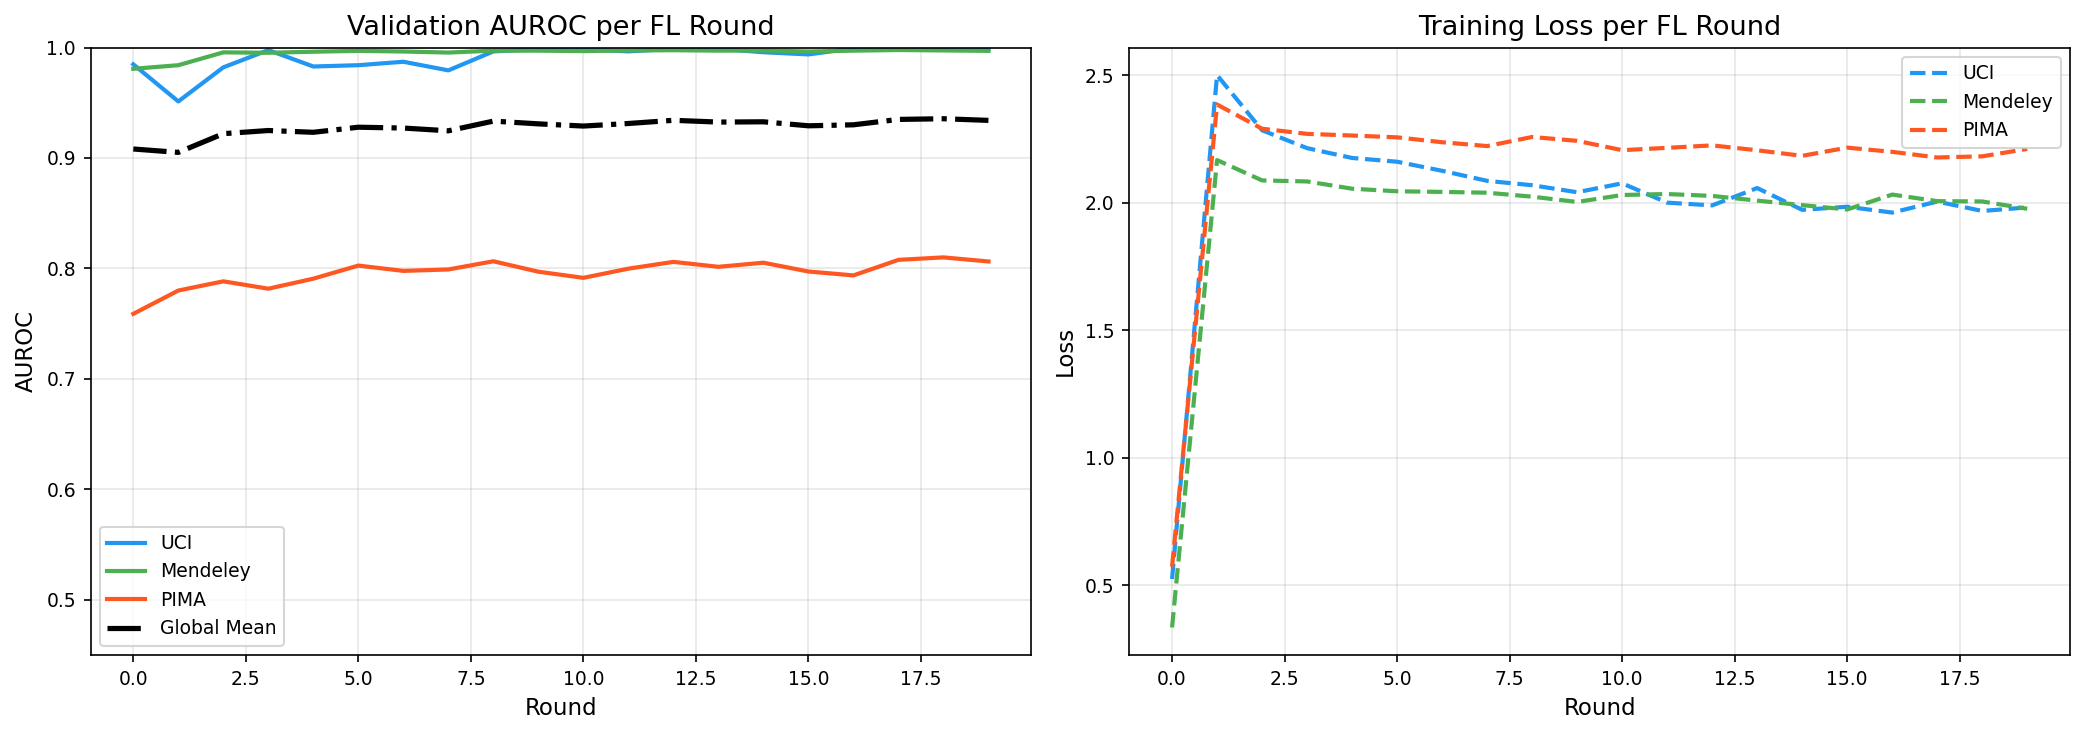

In [ ]:
# Training curves
print(f"{Style.BOLD} Training curves {Style.END}")
plot_training_curves(xftl_hist, clients_data)


In [ ]:
# Personalised fine-tuning
print(f"{Style.BOLD} Personalised fine-tuning {Style.END}")
for i, cd in enumerate(clients_data):
    xftl_models[i], auroc = personalized_finetune(
        xftl_models[i], cd["train_loader"], cd["val_loader"], n_epochs=10, device=DEVICE)
    print(f" {cd['name']:10s}: AUROC = {auroc:.4f}")

 Personalised fine-tuning 
 UCI       : AUROC = 0.9996
 Mendeley  : AUROC = 0.9977
 PIMA      : AUROC = 0.8102


In [ ]:
# Final evaluation + bootstrap CI
print(f"{Style.BOLD} Final FTL evaluation {Style.END}")
xftl_met, models_probs = {}, {}
for i, cd in enumerate(clients_data):
    met, probs, labels = evaluate_model(xftl_models[i], cd["val_loader"], DEVICE)
    xftl_met[cd["name"]] = met
    models_probs[cd["name"]] = (labels, probs)
    _, lo, hi = bootstrap_ci(labels, probs)
    print(f" {cd['name']:10s}: AUROC={met['AUROC']:.4f} 95%CI[{lo:.4f},{hi:.4f}] "
          f"F1={met['F1']:.4f} MCC={met['MCC']:.4f} "
          f"Sens={met['Sensitivity']:.4f} Spec={met['Specificity']:.4f}")

 Final FTL evaluation 
 UCI       : AUROC=0.9996 95%CI[0.9977,1.0000] F1=0.9844 MCC=0.9594 Sens=0.9844 Spec=0.9750
 Mendeley  : AUROC=0.9977 95%CI[0.9931,1.0000] F1=0.9911 MCC=0.9436 Sens=0.9882 Spec=0.9677
 PIMA      : AUROC=0.8102 95%CI[0.7307,0.8734] F1=0.6726 MCC=0.4846 Sens=0.7037 Spec=0.7900


 ROC curves 


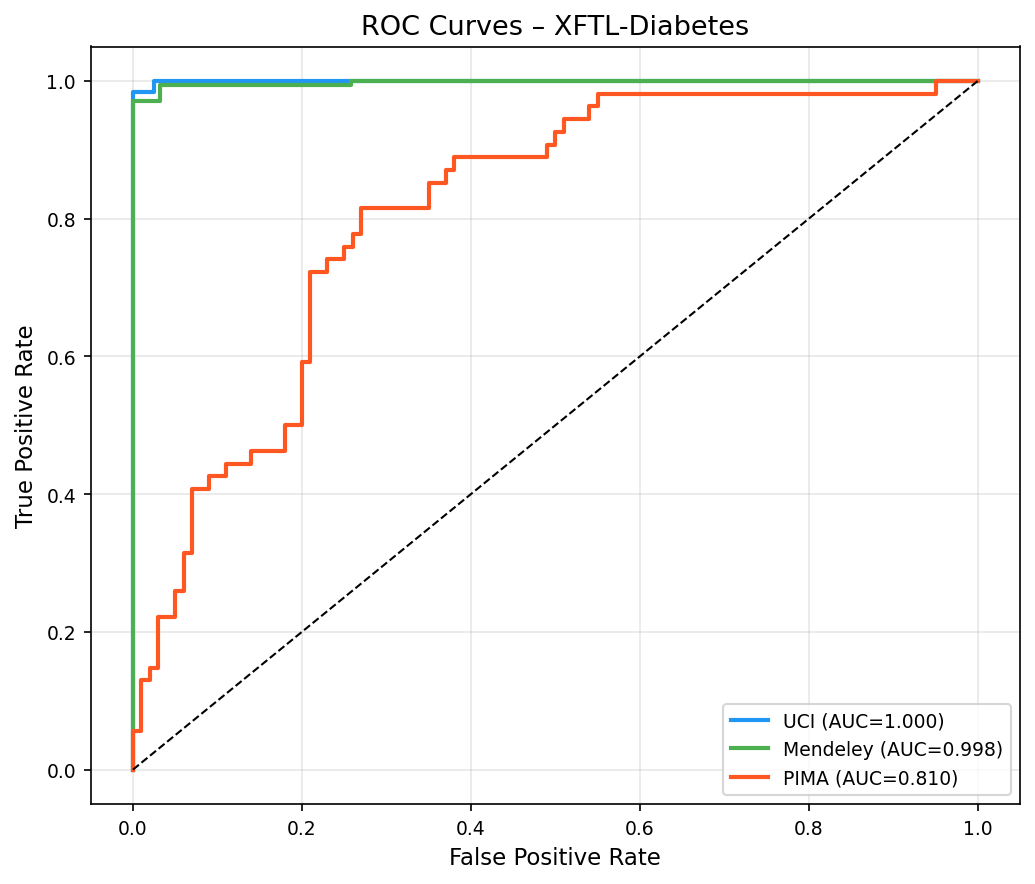

 Calibration curves 


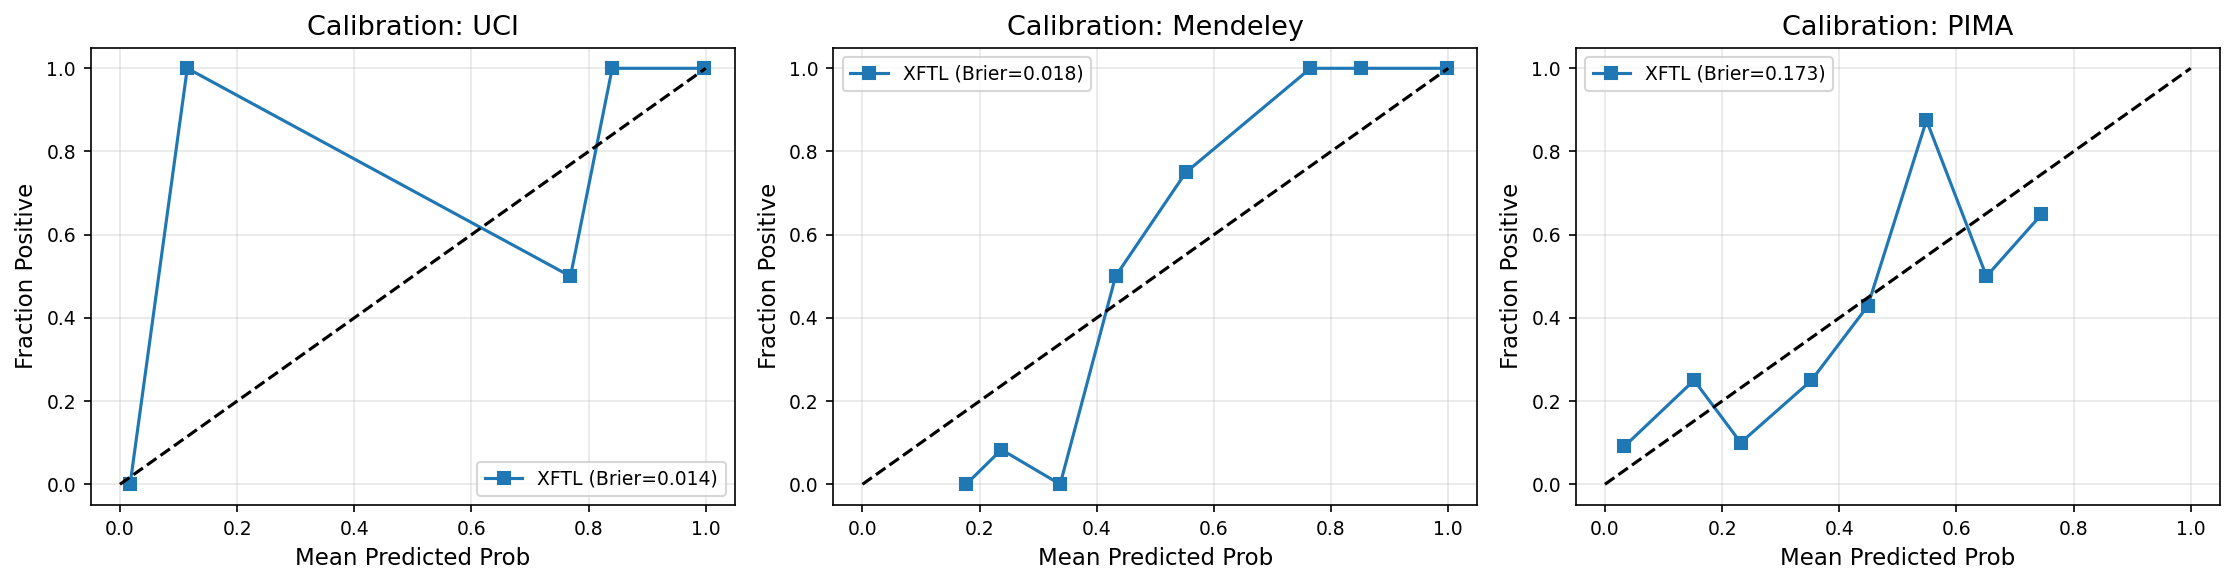


 Confusion matrices


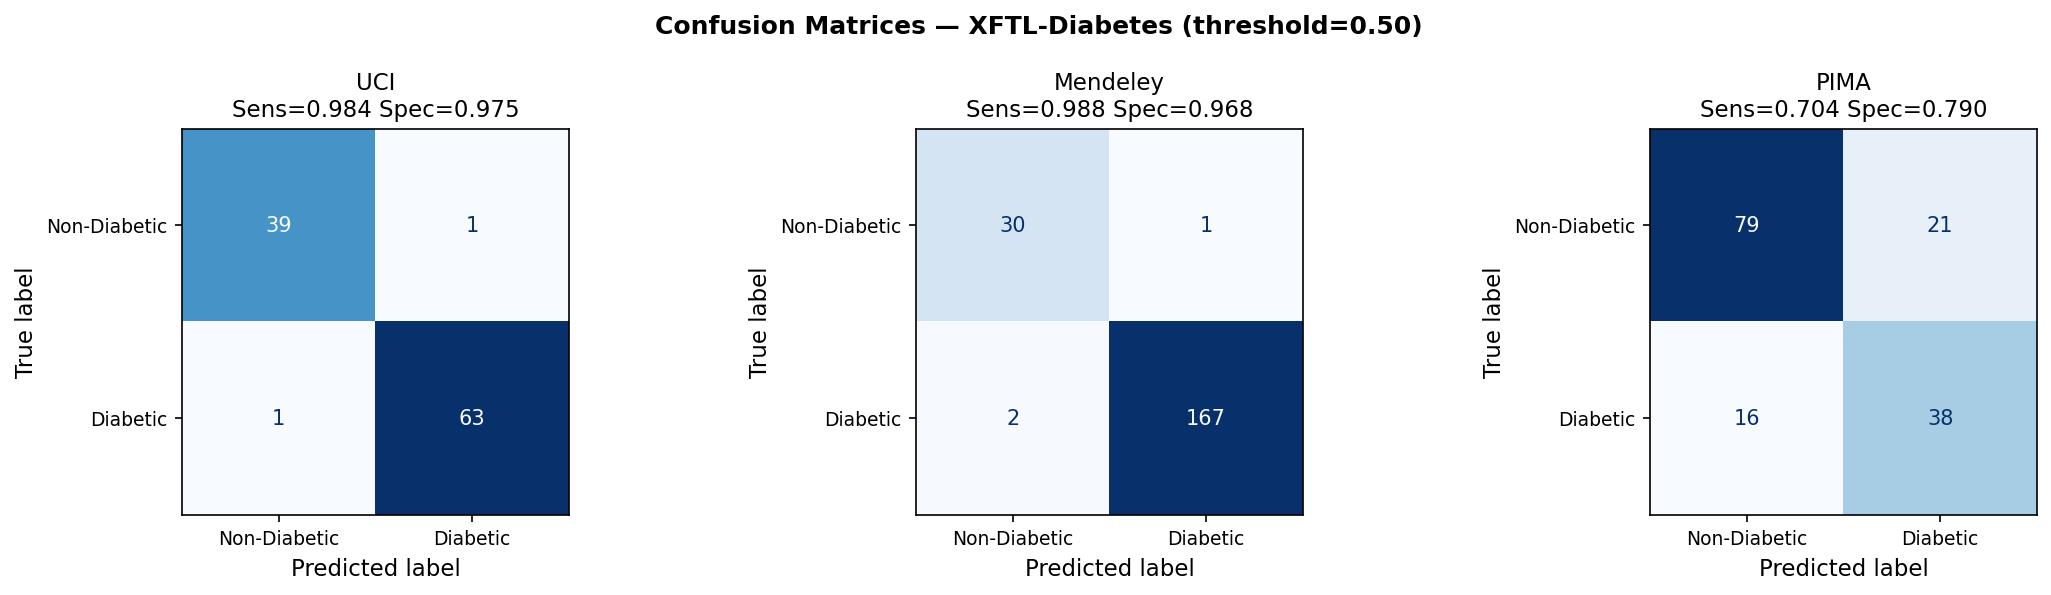

In [ ]:
# ROC, Calibration, Confusion Matrices
print(f"{Style.BOLD} ROC curves {Style.END}")
plot_roc_curves(models_probs)
print(f"{Style.BOLD} Calibration curves {Style.END}")
plot_calibration(models_probs)
print("\n Confusion matrices")
plot_confusion_matrices(models_probs)


Re-executing the `make_loader` and `cross_dataset_eval` definitions to resolve the `NotImplementedError`, then re-running the cross-dataset evaluation.

In [ ]:
# Re-execute the correct make_loader definition
def make_loader(X_t, y_t, batch_size=32, shuffle=True, drop_last=False):
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)

print("Correct `make_loader` function re-defined.")

Correct `make_loader` function re-defined.


In [ ]:
# Re-execute the cross_dataset_eval definition to pick up the correct make_loader
def cross_dataset_eval(models, clients_data, n_ft_epochs=5, ft_frac=0.10, latent_dim=64, proj_dim=32, device=DEVICE):
    """ Fixed leave-one-client-out transfer evaluation. Protocol: aggregate projector+shared_net from source clients → init target model → fine-tune only input_layer on ft_frac of target labels → evaluate. """
    results = {}
    n = len(clients_data)
    # Collect aggregated projector and shared_net states
    all_proj = [m.projector.state_dict() for m in models]
    all_shared = [m.encoder.shared_net.state_dict() for m in models]
    total_n = sum(cd["n_samples"] for cd in clients_data)
    w_all = [cd["n_samples"]/total_n for cd in clients_data]
    for ti in range(n):
        src_idx = [i for i in range(n) if i != ti]
        sw = sum(clients_data[i]["n_samples"] for i in src_idx)
        src_w = [clients_data[i]["n_samples"]/sw for i in src_idx]
        agg_proj = fedavg_aggregate([all_proj[i] for i in src_idx], src_w)
        agg_shared = fedavg_aggregate([all_shared[i] for i in src_idx], src_w)
        agg_gh = fedavg_aggregate([models[i].global_head.state_dict() for i in src_idx], src_w)
        # Build target model — use target client's input_dim
        tm = XFTLClient(clients_data[ti]["input_dim"], latent_dim, proj_dim, clients_data[ti].get("num_classes", 2)).to(device)
        tm.encoder.shared_net.load_state_dict(agg_shared)
        tm.projector.load_state_dict(agg_proj)
        tm.global_head.load_state_dict(agg_gh)
        # Freeze everything except input_layer; fine-tune on ft_frac of target data
        for name_, p in tm.named_parameters():
            p.requires_grad = "input_layer" in name_
        cd = clients_data[ti]
        n_ft = max(int(len(cd["y_train"]) * ft_frac), 8)
        idx = torch.randperm(len(cd["y_train"]))[:n_ft]
        ft_loader = make_loader(cd["X_train"][idx], cd["y_train"][idx], 16)
        opt_ft = torch.optim.Adam( [p for p in tm.parameters() if p.requires_grad], lr=5e-4)
        tm.train()
        for _ in range(n_ft_epochs):
            for X, y in ft_loader:
                X, y = X.to(device), y.to(device)
                opt_ft.zero_grad()
                logit, _ = tm(X, use_global=True)
                F.binary_cross_entropy_with_logits(logit.squeeze(), y.float()).backward()
                nn.utils.clip_grad_norm_(tm.parameters(), 1.0)
                opt_ft.step()
        for p in tm.parameters():
            p.requires_grad = True
        met, _, _ = evaluate_model(tm, cd["val_loader"], device)
        key = f"Transfer→{cd['name']}"
        results[key] = met
        print(f" {key}: AUROC={met['AUROC']:.4f} F1={met['F1']:.4f} " f"MCC={met['MCC']:.4f} (10% target labels for input_layer fine-tune)")
    return results

print("Correct `cross_dataset_eval` function re-defined.")

Correct `cross_dataset_eval` function re-defined.


In [ ]:
# Fixed cross-dataset transfer (projector-aligned)
print(f"{Style.BOLD} Cross-dataset transfer evaluation (fixed — SharedProjector alignment) {Style.END}")
cross_res = cross_dataset_eval(xftl_models, clients_data)

 Cross-dataset transfer evaluation (fixed — SharedProjector alignment) 
 Transfer→UCI: AUROC=0.4848 F1=0.7170 MCC=-0.1027 (10% target labels for input_layer fine-tune)
 Transfer→Mendeley: AUROC=0.8355 F1=0.9212 MCC=0.5564 (10% target labels for input_layer fine-tune)
 Transfer→PIMA: AUROC=0.5869 F1=0.5149 MCC=0.0073 (10% target labels for input_layer fine-tune)


 Extended low-resource transfer (1%–50% labels) 
 UCI        |   1% labels → AUROC=0.9996
 UCI        |   2% labels → AUROC=0.9996
 UCI        |   5% labels → AUROC=0.9996
 UCI        |  10% labels → AUROC=0.9996
 UCI        |  25% labels → AUROC=0.9996
 UCI        |  50% labels → AUROC=0.9996
 Mendeley   |   1% labels → AUROC=0.9977
 Mendeley   |   2% labels → AUROC=0.9977
 Mendeley   |   5% labels → AUROC=0.9977
 Mendeley   |  10% labels → AUROC=0.9971
 Mendeley   |  25% labels → AUROC=0.9975
 Mendeley   |  50% labels → AUROC=0.9973
 PIMA       |   1% labels → AUROC=0.8102
 PIMA       |   2% labels → AUROC=0.8102
 PIMA       |   5% labels → AUROC=0.8080
 PIMA       |  10% labels → AUROC=0.8109
 PIMA       |  25% labels → AUROC=0.8141
 PIMA       |  50% labels → AUROC=0.8126
 Sample efficiency curve 


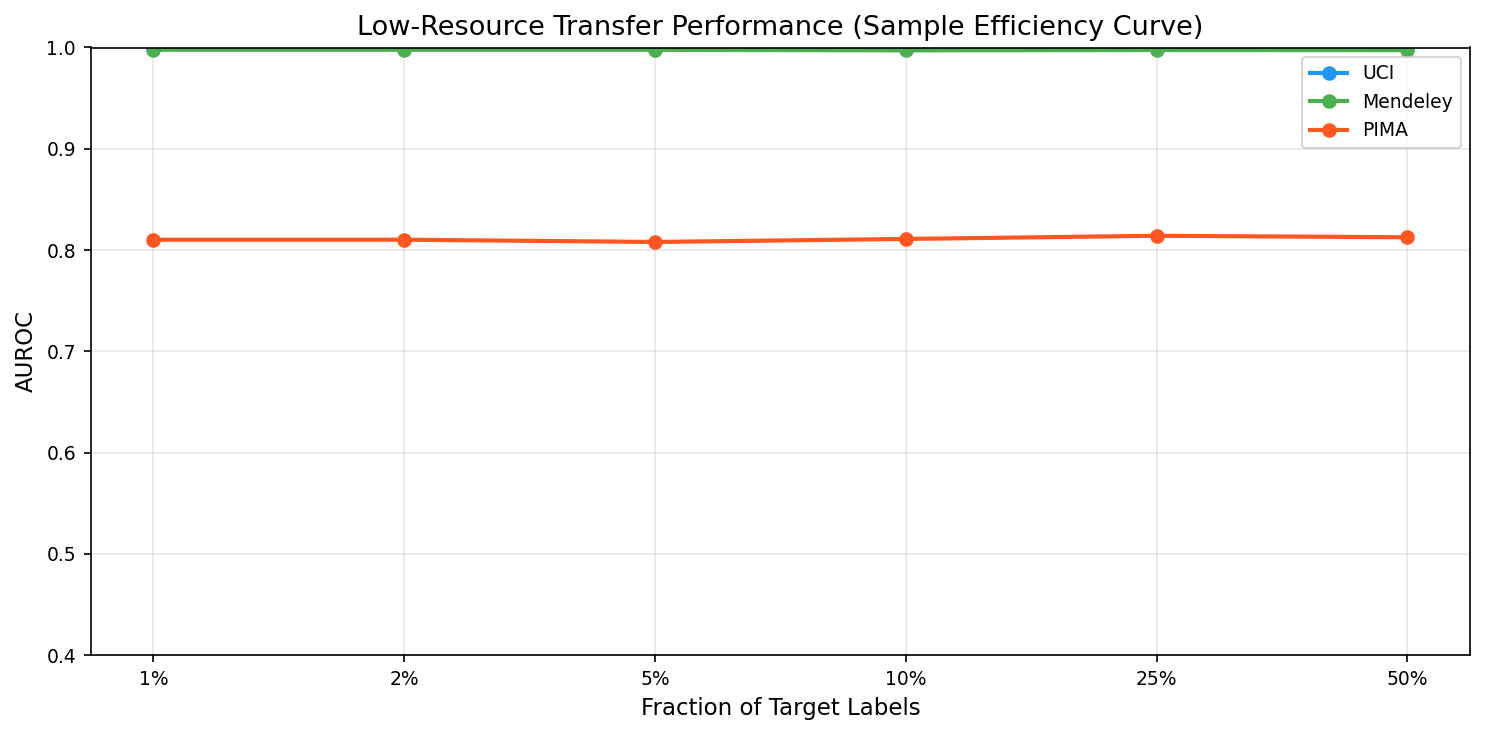

In [ ]:
# Extended low-resource evaluation (1%–50%)
print(f"{Style.BOLD} Extended low-resource transfer (1%–50% labels) {Style.END}")
lr_res = low_resource_eval(xftl_models, clients_data, fracs=(0.01, 0.02, 0.05, 0.10, 0.25, 0.50))
print(f"{Style.BOLD} Sample efficiency curve {Style.END}")
plot_low_resource(lr_res)

### Ablation Study

 Ablation Study 
 Ablation: Full XFTL
 → mean AUROC=0.9391
 Ablation: No Contrastive
 → mean AUROC=0.9347
 Ablation: No Domain
 → mean AUROC=0.9395
 Ablation: No FedProx
 → mean AUROC=0.9368
 Ablation: No Alignment
 → mean AUROC=0.9376
 Ablation Plot 


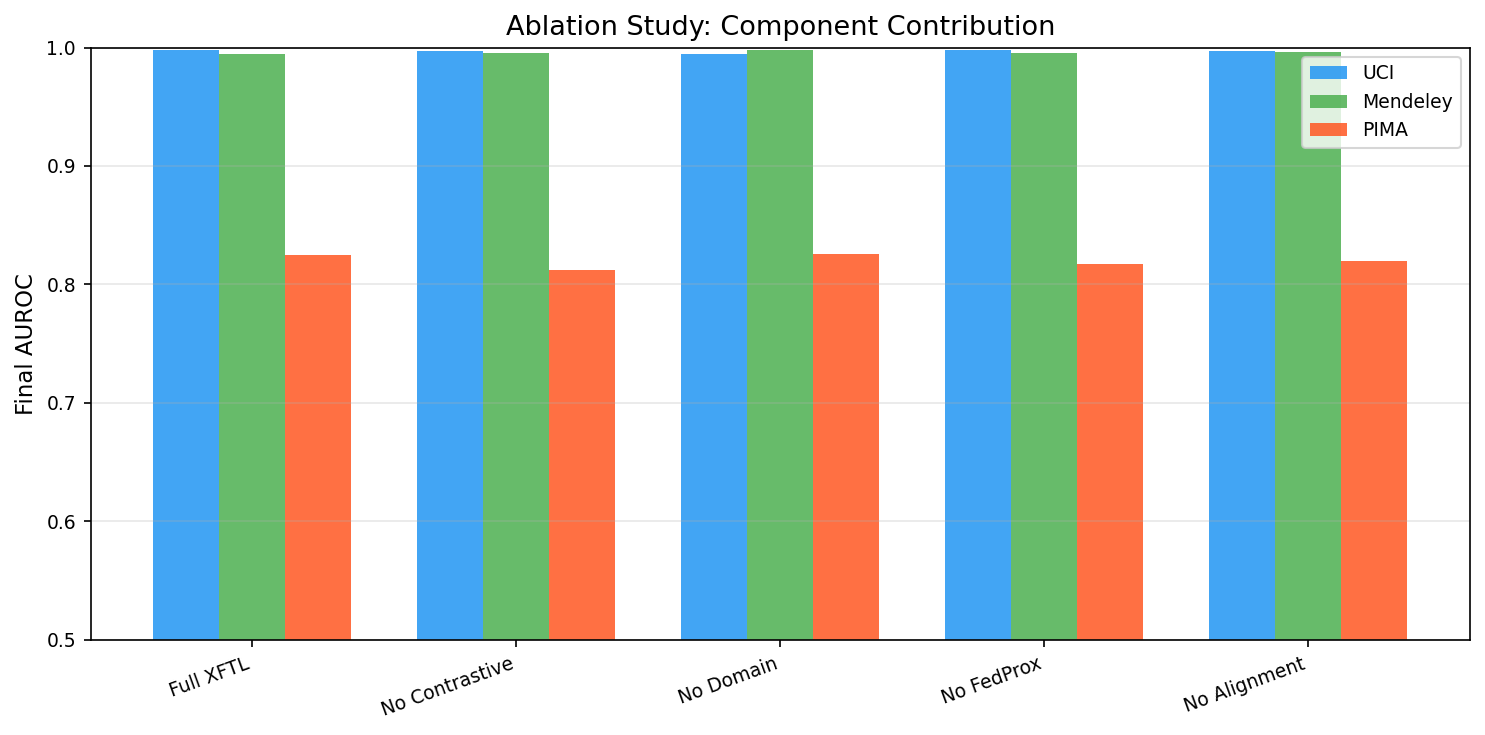

In [ ]:
# Ablation Study: Contribution of XFTL Components
print(f"{Style.BOLD} Ablation Study {Style.END}")
abl_results = run_ablation(clients_data, device=DEVICE)
print(f"{Style.BOLD} Ablation Plot {Style.END}")
plot_ablation(abl_results)



Non-IID Dirichlet heterogeneity experiment (α = 0.1, 0.5, 1.0) 

 α = 0.1
 XFTL UCI: AUROC=1.0000
 XFTL Mendeley: AUROC=1.0000
 XFTL PIMA: AUROC=1.0000
 FedAvg UCI: AUROC=1.0000
 FedAvg Mendeley: AUROC=1.0000
 FedAvg PIMA: AUROC=1.0000

 α = 0.5
 XFTL UCI: AUROC=0.6395
 XFTL Mendeley: AUROC=0.7175
 XFTL PIMA: AUROC=0.4103
 FedAvg UCI: AUROC=0.6672
 FedAvg Mendeley: AUROC=0.7788
 FedAvg PIMA: AUROC=0.6167

 α = 1.0
 XFTL UCI: AUROC=0.9739
 XFTL Mendeley: AUROC=0.9691
 XFTL PIMA: AUROC=0.8488
 FedAvg UCI: AUROC=0.7246
 FedAvg Mendeley: AUROC=0.9416
 FedAvg PIMA: AUROC=0.8140
 Non-IID robustness plot


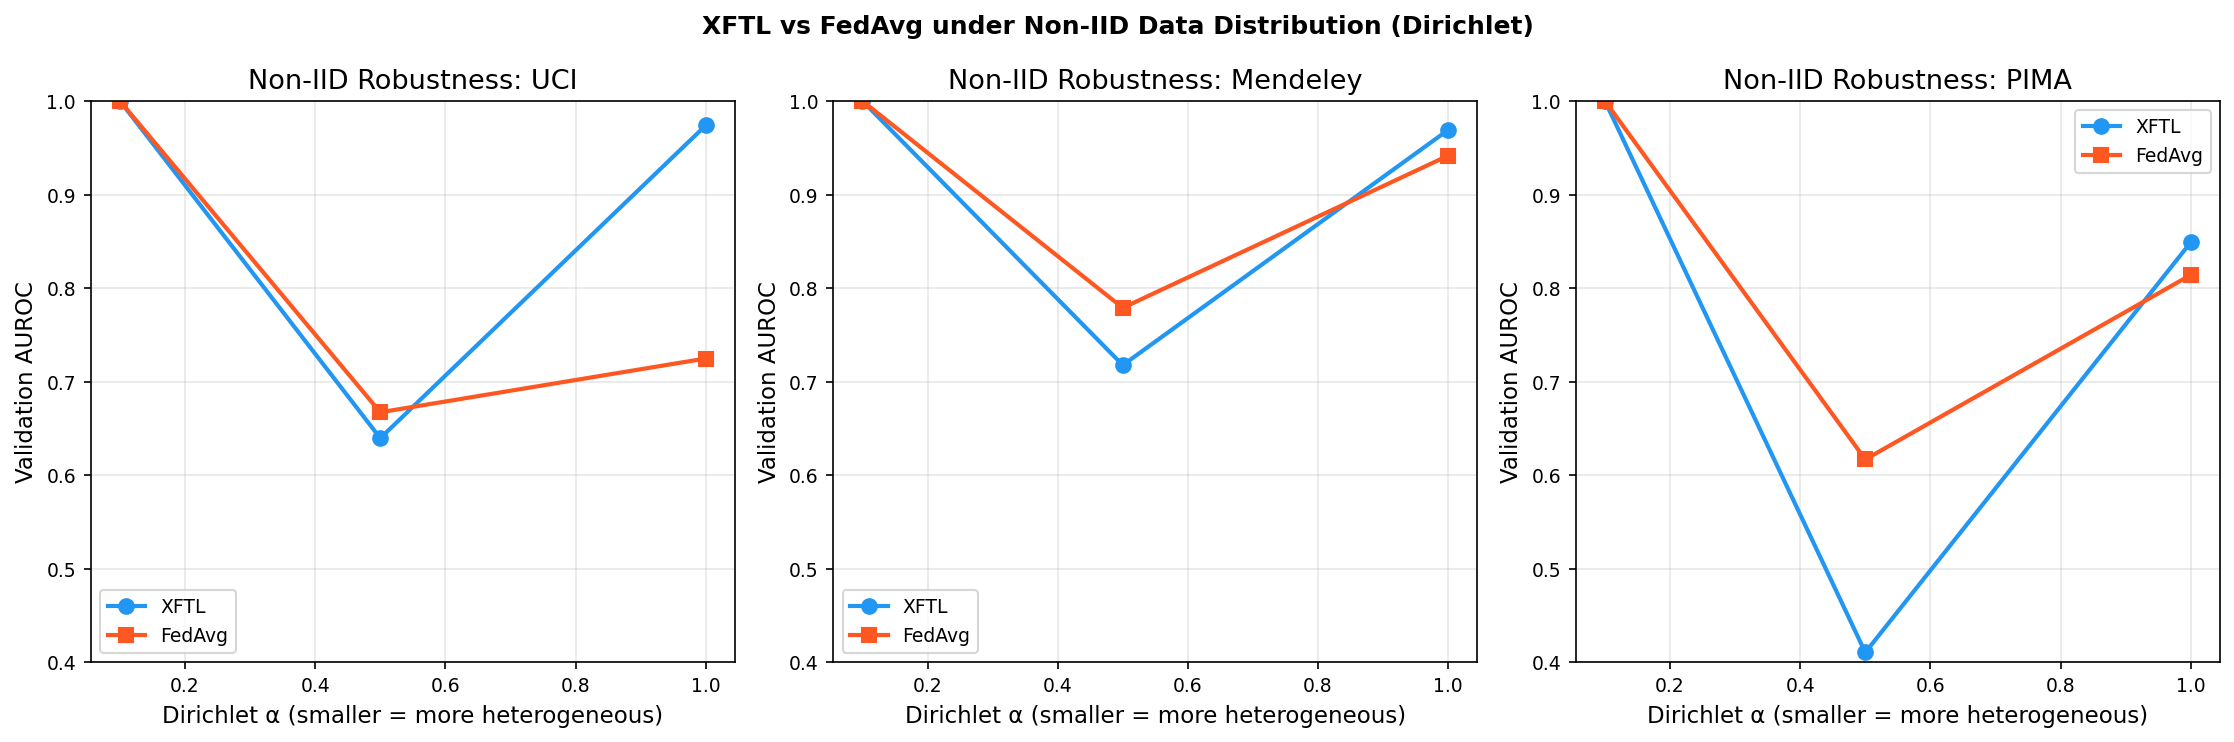

In [ ]:
# Non-IID Dirichlet experiment (was coded but never run)
print(f"{Style.BOLD}Non-IID Dirichlet heterogeneity experiment (α = 0.1, 0.5, 1.0) {Style.END}")
alphas = [0.1, 0.5, 1.0]
dirichlet_results = {}
for alpha in alphas:
    print(f"\n α = {alpha}")
    # Split each full dataset by Dirichlet
    df_maps = {"UCI": df_uci, "Mendeley": df_men, "PIMA": df_pim}
    feat_maps= {"UCI": feats_uci, "Mendeley": feats_men, "PIMA": feats_pim}
    dir_clients = []
    for ds in ["UCI","Mendeley","PIMA"]:
        splits_raw = dirichlet_split(df_maps[ds], alpha=alpha)

        # Filter out empty dataframes and collect them
        non_empty_splits = [s for s in splits_raw if not s.empty]

        if len(non_empty_splits) < 2:
            print(f"Warning: Not enough non-empty Dirichlet splits (need at least 2 for train/val) for {ds} with alpha={alpha}. Skipping client.")
            continue

        # Take the first non-empty split for training
        df_tr = non_empty_splits[0]

        # Take the second non-empty split for validation
        df_va = non_empty_splits[1]

        # NEW: Skip client if training dataset has fewer than 2 samples to avoid BatchNorm error
        if len(df_tr) < 2:
            print(f"Warning: Training dataset for {ds} with alpha={alpha} has {len(df_tr)} samples, which is too small for BatchNorm. Skipping client.")
            continue

        # Double-check if df_tr or df_va are still somehow empty (should not happen with this logic, but for safety)
        if df_tr.empty or df_va.empty:
             print(f"Error: df_tr or df_va is empty after selection for {ds} with alpha={alpha}. Skipping client.")
             continue

        feat = feat_maps[ds]
        Xtr, ytr, sc = prepare_tensors(df_tr, feat)
        Xva, yva, _ = prepare_tensors(df_va, feat, sc, fit_scaler=False)
        dir_clients.append({
            "name": ds,
            "input_dim": len(feat),
            "n_samples": len(df_tr),
            "num_classes": 2,
            "feature_cols": feat,
            "train_loader": make_loader(Xtr, ytr, 32, drop_last=True),
            "val_loader": make_loader(Xva, yva, 64, shuffle=False, drop_last=False),
            "X_train":Xtr,"y_train":ytr,"X_val":Xva,"y_val":yva,
        })

    # If no clients remain after filtering, skip this alpha
    if not dir_clients:
        print(f"Warning: No valid clients for alpha={alpha} after filtering. Skipping experiment for this alpha.")
        continue

    # XFTL under Dirichlet
    dm, _ = run_xftl(dir_clients, n_rounds=10, local_epochs=3, verbose=False, device=DEVICE)
    xftl_dir = {}
    for i, cd in enumerate(dir_clients):
        met, _, _ = evaluate_model(dm[i], cd["val_loader"], DEVICE)
        xftl_dir[cd["name"]] = met["AUROC"]
        print(f" XFTL {cd['name']}: AUROC={met['AUROC']:.4f}")
    # FedAvg under Dirichlet
    fm, fh = run_fedavg_baseline(dir_clients, n_rounds=10, local_epochs=3, device=DEVICE)
    favg_dir = {cd["name"]: fh[cd["name"]]["val_auroc"][-1] for cd in dir_clients}
    for ds, v in favg_dir.items():
        print(f" FedAvg {ds}: AUROC={v:.4f}")
    dirichlet_results[alpha] = {"XFTL": xftl_dir, "FedAvg": favg_dir}
print(f" {Style.BOLD}Non-IID robustness plot{Style.END}")
plot_dirichlet(dirichlet_results)


In [ ]:
# SHAP Analysis
print(f"{Style.BOLD}SHAP analysis {Style.END}")
shap_results = {}
grp_maps = {"UCI": grp_uci, "Mendeley": grp_men, "PIMA": grp_pim}
for i, cd in enumerate(clients_data):
    print(f"\n Computing SHAP for {cd['name']} …")
    sv, Xexp, feats = compute_shap_values(
        xftl_models[i], cd["X_val"], cd["feature_cols"], n_bg=30, n_exp=50)
    ga = grp_maps[cd["name"]]
    shap_results[cd["name"]] = (sv, Xexp, list(feats), ga)
    cg = clinical_group_shap(sv, list(feats), ga)
    print(f" Clinical group importance: {cg}")
print(f"\n {Style.BOLD}Cross-client SHAP stability {Style.END}")
names_ = list(shap_results)
for j in range(len(names_)):
    for k in range(j+1, len(names_)):
        r, p = shap_rank_stability(shap_results[names_[j]][0], shap_results[names_[k]][0])
        jac = jaccard_topk(shap_results[names_[j]][0], shap_results[names_[k]][0], k=5)
        print(f" {names_[j]} vs {names_[k]}: Spearman r={r:.3f} p={p:.4f} Jaccard@5={jac:.3f}")


SHAP analysis 

 Computing SHAP for UCI …
 Clinical group importance: {'symptoms': 0.8661543083260066, 'demographic': 0.13384567659193847}

 Computing SHAP for Mendeley …
 Clinical group importance: {'glycemic': 0.34786391306653514, 'anthropometric': 0.30241315429325655, 'lipid': 0.19401752084045523, 'demographic': 0.12939609783136352, 'renal_metabolic': 0.02630928512291513}

 Computing SHAP for PIMA …
 Clinical group importance: {'glycemic': 0.3069567338668515, 'anthropometric': 0.2579486835591305, 'demographic': 0.2415909576740444, 'lipid': 0.1364978133435899, 'renal_metabolic': 0.05700578720891378}

 Cross-client SHAP stability 
 UCI vs Mendeley: Spearman r=-0.273 p=0.4171 Jaccard@5=0.250
 UCI vs PIMA: Spearman r=-0.381 p=0.3518 Jaccard@5=0.111
 Mendeley vs PIMA: Spearman r=0.381 p=0.3518 Jaccard@5=0.429


SHAP comparison (mean |SHAP|)


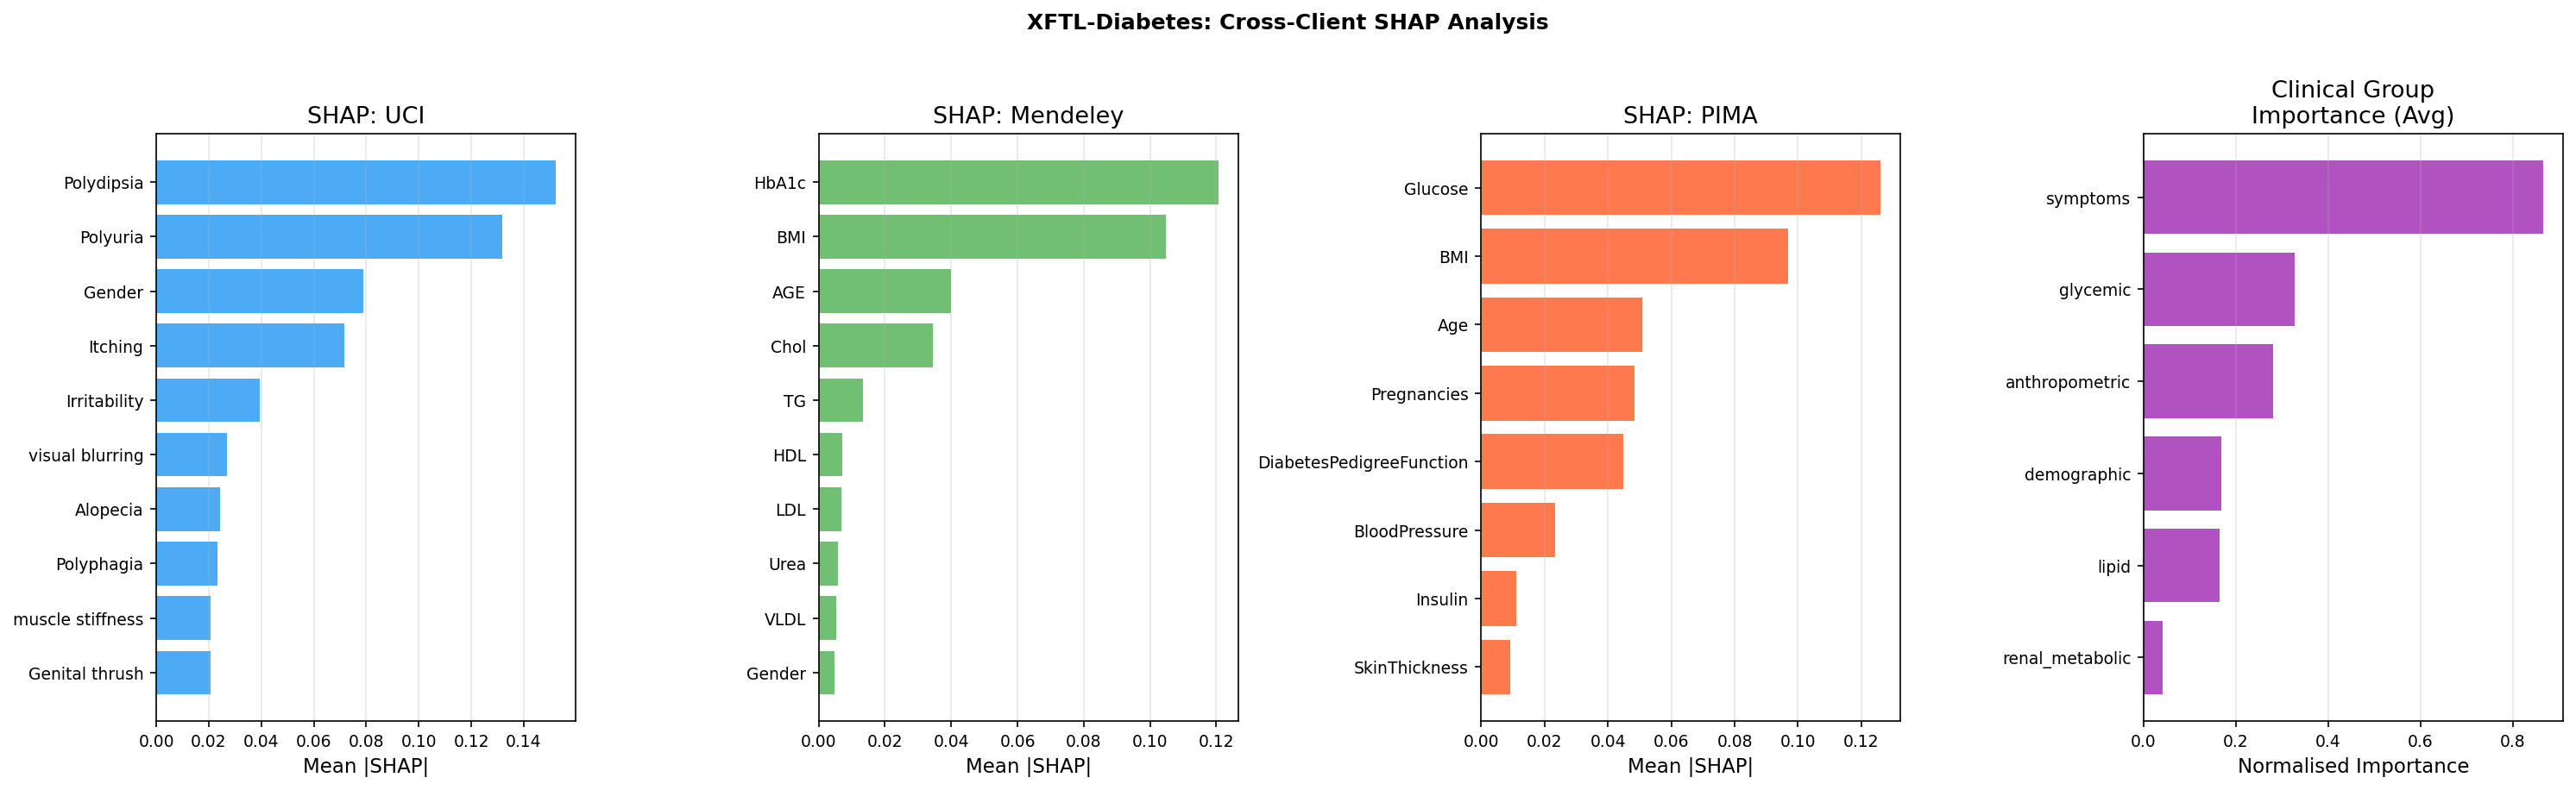


 SHAP beeswarm plots 


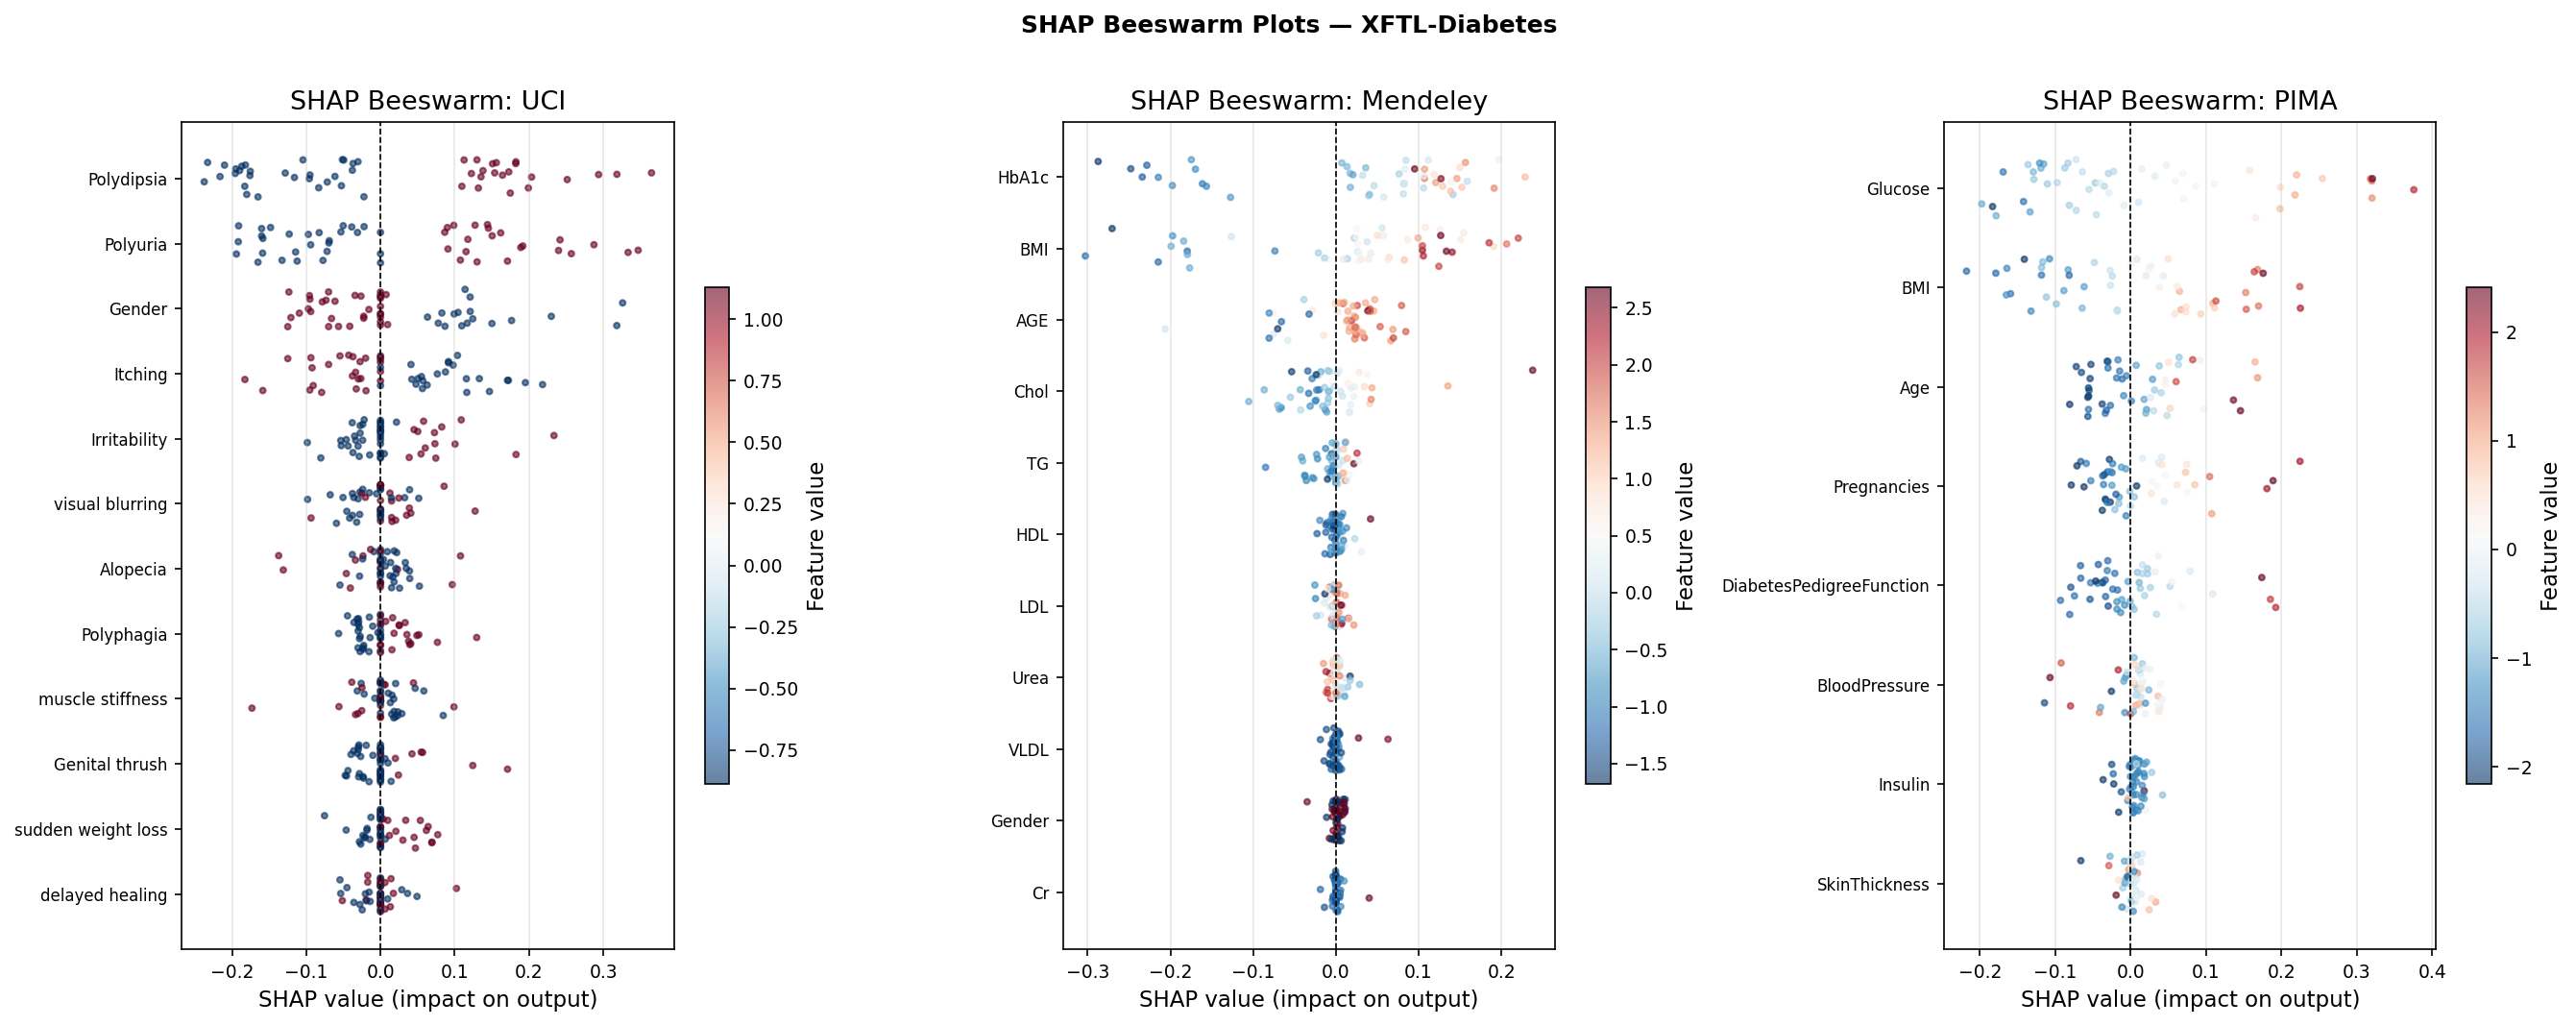


 SHAP waterfall plots


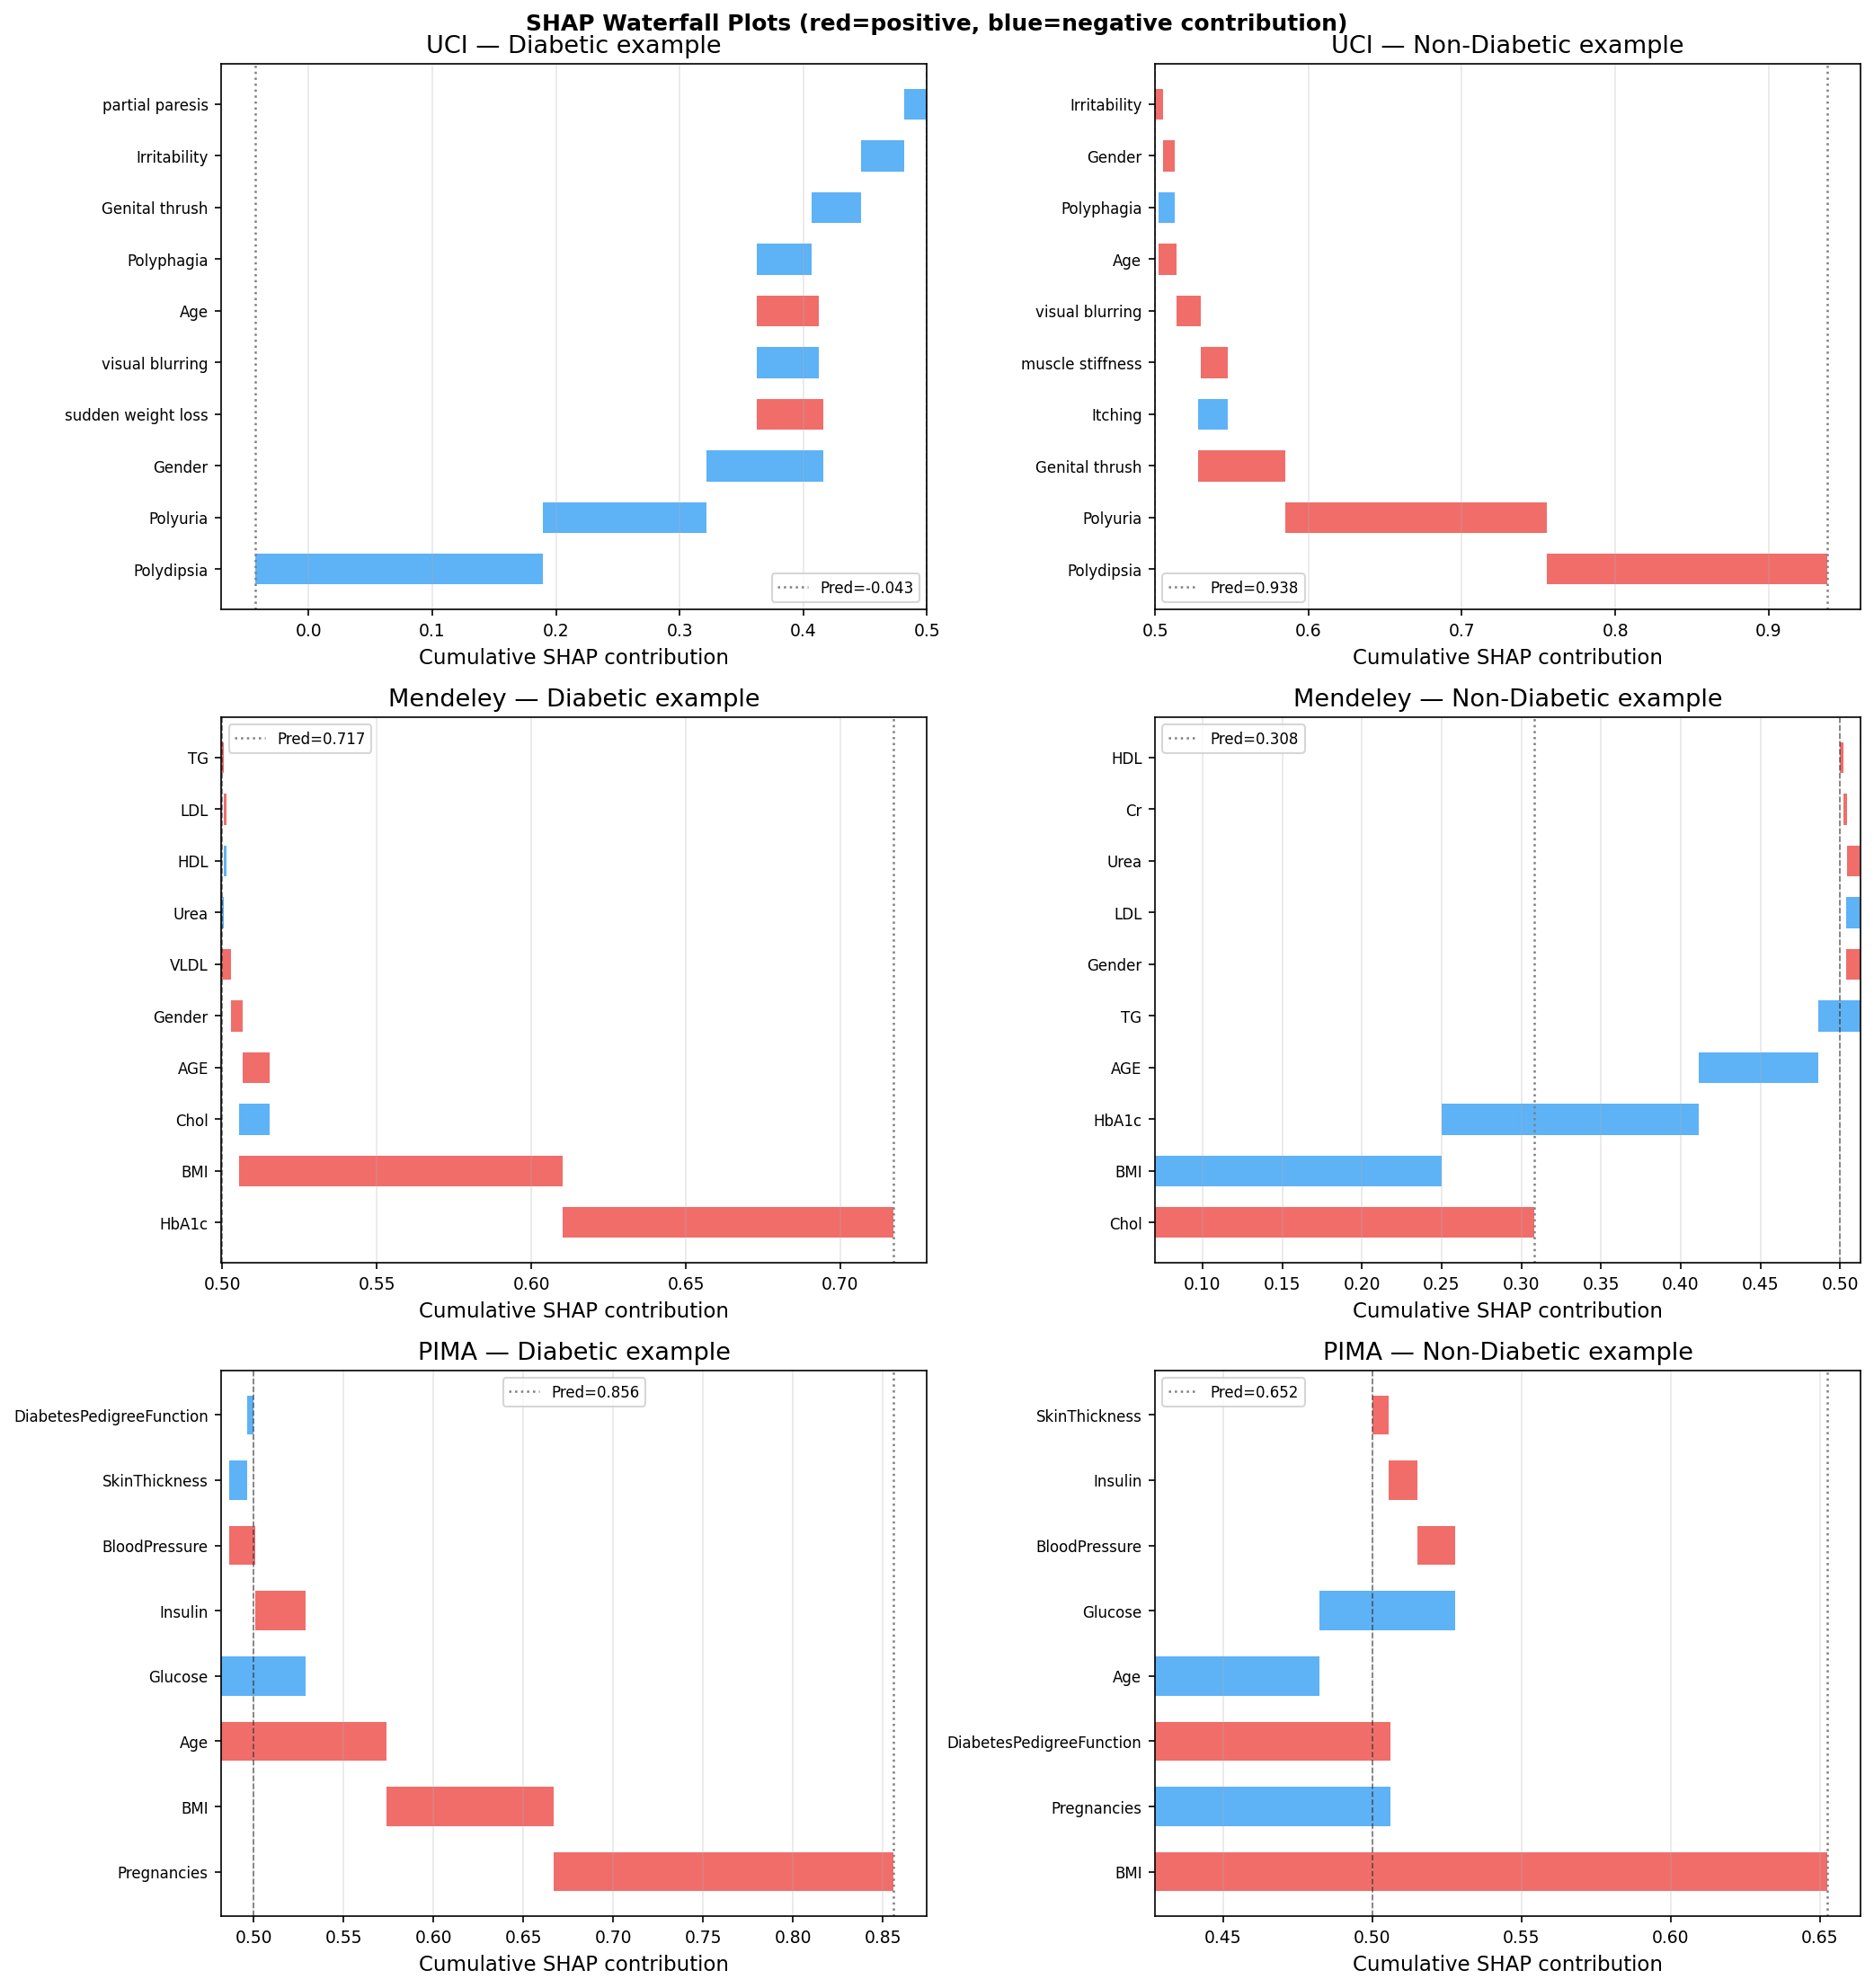

In [ ]:
# SHAP plots
print(f"{Style.BOLD}SHAP comparison (mean |SHAP|){Style.END}")
plot_shap_comparison(shap_results)
print(f"\n {Style.BOLD}SHAP beeswarm plots {Style.END}")
plot_shap_beeswarm(shap_results)
print(f"\n {Style.BOLD}SHAP waterfall plots{Style.END}")
plot_shap_waterfall(shap_results, clients_data)


In [ ]:
# LIME explanations
print(f" {Style.BOLD} LIME instance-level explanations {Style.END}")
for i, cd in enumerate(clients_data):
    print(f"\n — {cd['name']} (3 instances) —")
    lime_exps = compute_lime_explanations(
        xftl_models[i], cd["X_train"].numpy(), cd["X_val"].numpy()[:20], cd["feature_cols"], n_samples=3)
    for idx_exp, exp in enumerate(lime_exps):
        top = exp.as_list()[:5]
        print(f" Instance {idx_exp+1}: {[(f, round(w,4)) for f,w in top]}")


  LIME instance-level explanations 

 — UCI (3 instances) —
 Instance 1: [('Alopecia <= -0.71', 0.0047), ('Polydipsia <= -0.89', -0.0033), ('visual blurring <= -0.91', 0.0028), ('sudden weight loss <= -0.86', -0.0028), ('Genital thrush <= -0.54', -0.0026)]
 Instance 2: [('Alopecia <= -0.71', 0.0027), ('-0.89 < Polydipsia <= 1.13', 0.0023), ('sudden weight loss <= -0.86', -0.0018), ('Genital thrush <= -0.54', -0.0016), ('Age <= -0.76', 0.0016)]
 Instance 3: [('Alopecia <= -0.71', 0.004), ('-0.89 < Polydipsia <= 1.13', 0.0029), ('sudden weight loss <= -0.86', -0.0025), ('Genital thrush <= -0.54', -0.0022), ('visual blurring <= -0.91', 0.0021)]

 — Mendeley (3 instances) —
 Instance 1: [('-0.09 < HbA1c <= 0.74', 0.1102), ('Cr > 0.06', 0.0292), ('-0.09 < LDL <= 0.62', 0.0212), ('-1.16 < Gender <= 0.86', -0.014), ('-0.05 < Chol <= 0.50', 0.0108)]
 Instance 2: [('HbA1c <= -0.69', -0.2594), ('BMI <= -0.73', -0.2304), ('AGE <= -0.28', -0.1052), ('-0.68 < Chol <= -0.05', -0.0204), ('VLDL <= -0.

In [ ]:
# Privacy MIA analysis
print(f"{Style.BOLD} Privacy — Membership Inference Attack {Style.END}")
privacy_res = run_privacy_analysis(xftl_models, clients_data)


 Privacy — Membership Inference Attack 

 MIA results (AUROC closer to 0.50 = better privacy):
 Client     MIA AUROC    Advantage    Privacy   
 ----------------------------------------------
 UCI        0.4254 0.0000 Good
 Mendeley   0.5020 0.0040 Good
 PIMA       0.5370 0.0740 Good


In [ ]:
# Communication cost
print(f" {Style.BOLD} Communication cost analysis {Style.END}")
comm_res = communication_cost_analysis(xftl_models, clients_data, xftl_hist, n_rounds=20)


  Communication cost analysis 
 Aggregated parameters/round : 6,528 (4,384 shared_net + 2,144 projector)
 Bytes exchanged / round : 76.5 KB (3 clients × upload+download)
 Total bytes (20 rounds) : 1530.0 KB
 Centralised upload equiv. : 79.6 KB
 Communication saving : -1823.0% less data transmitted than centralised


 Repeated 5-fold CV + Wilcoxon signed-rank tests 
 (This runs 5 full FL training loops — may take several minutes)
 Running 5-fold CV (15 FL rounds/fold) …
 Fold 1/5 … XFTL mean so far: {'UCI': np.float64(0.9984375), 'Mendeley': np.float64(0.9833937774384425), 'PIMA': np.float64(0.8859259259259259)}
 Fold 2/5 … XFTL mean so far: {'UCI': np.float64(0.991015625), 'Mendeley': np.float64(0.9872112998663867), 'PIMA': np.float64(0.8542592592592593)}
 Fold 3/5 … XFTL mean so far: {'UCI': np.float64(0.9932291666666666), 'Mendeley': np.float64(0.989247311827957), 'PIMA': np.float64(0.8524691358024691)}
 Fold 4/5 … XFTL mean so far: {'UCI': np.float64(0.994140625), 'Mendeley': np.float64(0.985827447986257), 'PIMA': np.float64(0.8525462962962963)}
 Fold 5/5 … XFTL mean so far: {'UCI': np.float64(0.994375), 'Mendeley': np.float64(0.9845390341668259), 'PIMA': np.float64(0.8503703703703703)}

  CV boxplots 


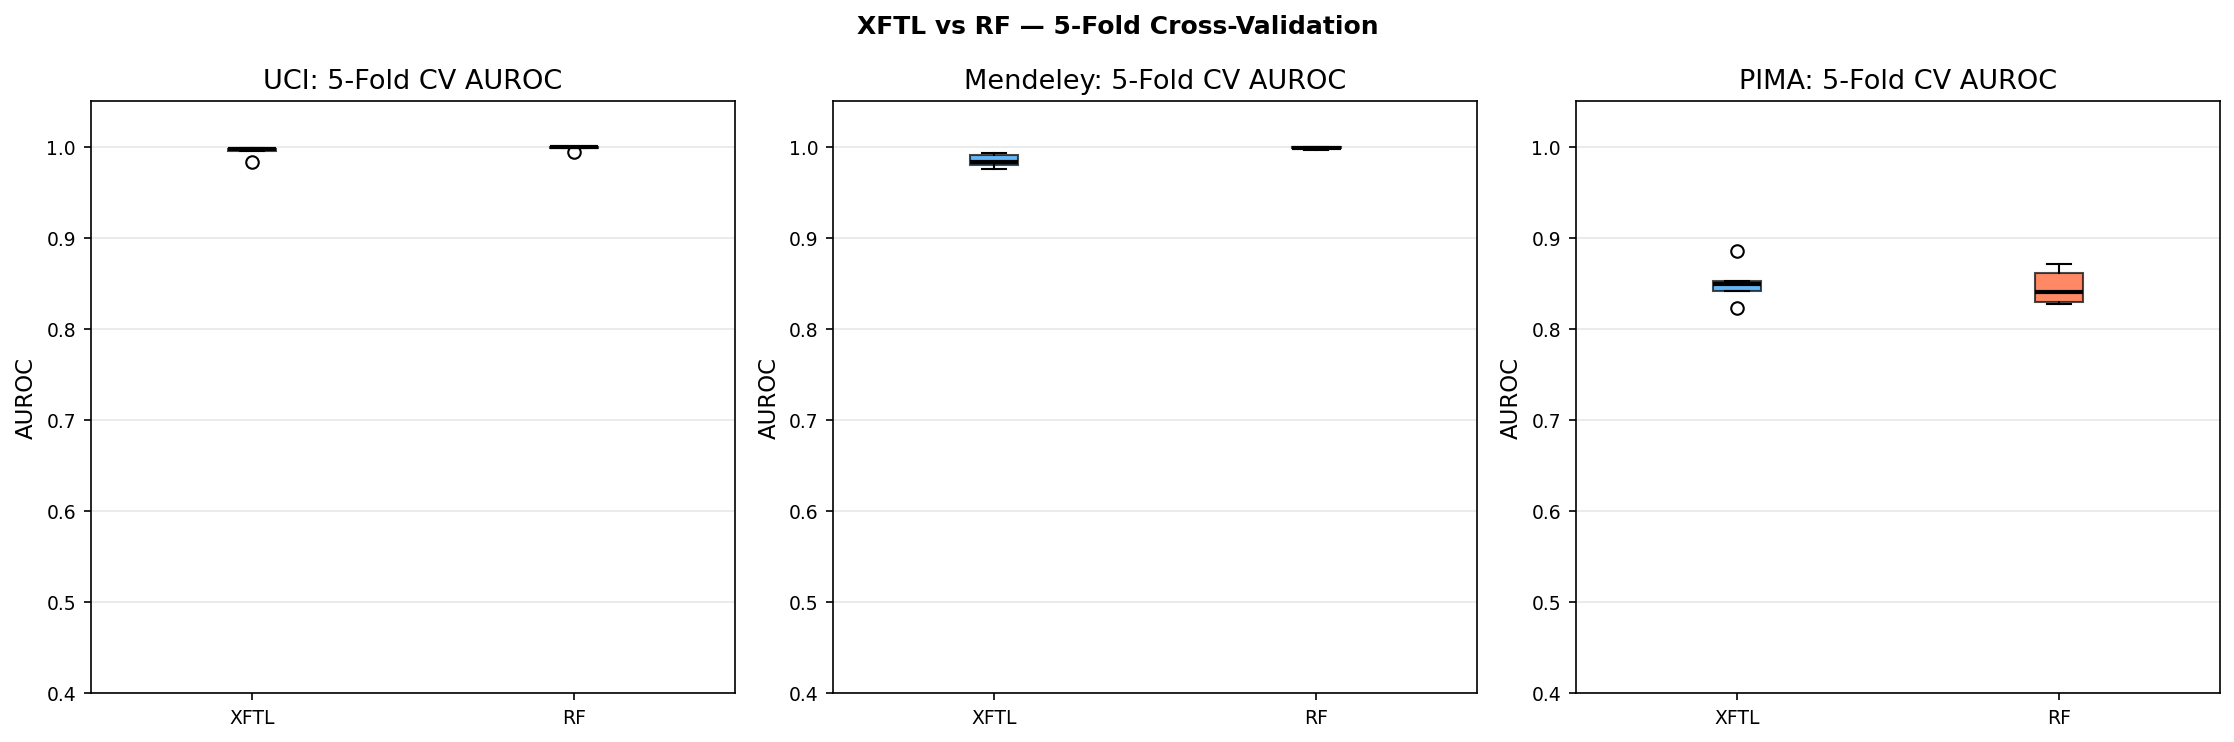


 Statistical significance summary (Bonferroni-corrected) 

Dataset      XFTL AUROC           RF AUROC             p (Wilcoxon)   Sig?   Δ AUROC   
 UCI        XFTL=0.9944±0.0055 RF=0.9982±0.0020 p=1.0000 X Δ=-0.0039
 Mendeley   XFTL=0.9845±0.0067 RF=0.9984±0.0012 p=1.0000 X Δ=-0.0139
 PIMA       XFTL=0.8504±0.0206 RF=0.8459±0.0175 p=0.1562 X Δ=+0.0044

Bonferroni-corrected α = 0.0167 (α=0.05/k=3)


In [ ]:
# Repeated 5-fold CV + Statistical tests
print(f"{Style.BOLD} Repeated 5-fold CV + Wilcoxon signed-rank tests {Style.END}")
print(" (This runs 5 full FL training loops — may take several minutes)")
df_dict = {"UCI": df_uci, "Mendeley": df_men, "PIMA": df_pim}
feat_dict = {"UCI": feats_uci, "Mendeley": feats_men, "PIMA": feats_pim}
cv_aurocs = run_repeated_cv(df_dict, feat_dict, n_splits=5, n_rounds_fl=15)
print(f"\n {Style.BOLD} CV boxplots {Style.END}")
plot_cv_boxplot(cv_aurocs)
print(f"\n {Style.BOLD}Statistical significance summary (Bonferroni-corrected) {Style.END}")
print_cv_results_and_stats(cv_aurocs)

In [ ]:
# Comprehensive results table
print(f"{Style.BOLD} Comprehensive results table {Style.END}")
all_results = {"XFTL-Diabetes": {cd["name"]: xftl_met[cd["name"]] for cd in clients_data}}
print_results_table(all_results)


 Comprehensive results table 

Model                 Client      AUROC       AUPRC       F1          BalancedAcc MCC         Sensitivity Specificity Brier       
XFTL-Diabetes         UCI         0.9996      0.9998      0.9844      0.9797      0.9594      0.9844      0.9750      0.0140      
XFTL-Diabetes         Mendeley    0.9977      0.9996      0.9911      0.9780      0.9436      0.9882      0.9677      0.0182      
XFTL-Diabetes         PIMA        0.8102      0.6752      0.6726      0.7469      0.4846      0.7037      0.7900      0.1725      
